# Analyse des sources d'avis

## les imports


In [1]:
#les imports centralisés et options
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns


import plotly.express as px

import bs4
from wordcloud import WordCloud 
import urllib.request
import spacy
import time
import os
import sys
import subprocess
import platform

from sentence_transformers import SentenceTransformer
import importlib

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)



## 👓lecture des données

In [22]:
df40=pd.read_csv(Path("data/avis_40k.csv"),sep=";")
df20=pd.read_csv(Path("data/reviews_20k.csv"),sep=";")
display(df20.head(),df40.head()
  ,df20[df20["consumer.displayName"]=="GM"].head()
  ,df40[df40["auteur"]=="GM"].head()
)


,_page,consumer.countryCode,consumer.displayName,consumer.hasImage,consumer.id,consumer.imageUrl,consumer.isVerified,consumer.numberOfReviews,consumersReviewCountOnSameDomain,consumersReviewCountOnSameLocation,dates.experiencedDate,dates.publishedDate,dates.submittedDate,dates.updatedDate,filtered,hasUnhandledReports,id,isPending,labels.merged,labels.verification.createdDateTime,labels.verification.hasDachExclusion,labels.verification.isVerified,labels.verification.reviewSourceName,labels.verification.verificationLevel,labels.verification.verificationSource,language,likes,location,rating,reply,report,source,text,title,reply.message,reply.publishedDate,reply.updatedDate
0,1,FR,Francis Hibon,False,61d6e3b82d936600126194d9,NaN,False,5,3,NaN,2026-02-14T00:00:00.000Z,2026-02-15T19:01:12.000Z,NaN,NaN,False,False,6991fbd8ebb90f335f3e0eee,False,NaN,2026-02-15T19:01:12.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,Moins cher que dans les garages automobile,Moins cher que dans les garages …,NaN,NaN,NaN
1,1,FR,Baisnée,False,6991fabcb2781e0f262a8c10,NaN,False,1,1,NaN,2026-02-13T00:00:00.000Z,2026-02-15T18:56:29.000Z,NaN,NaN,False,False,6991fabd9c9705038eaea70e,False,NaN,2026-02-15T18:56:29.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,"livraison parfaite, le livreur très professionnel",livraison parfaite,NaN,NaN,NaN
2,1,FR,EMILIE MOUVAULT,False,653b7399ea197500123124da,NaN,False,5,1,NaN,2026-02-15T00:00:00.000Z,2026-02-15T18:54:33.000Z,NaN,NaN,False,False,6991fa494ac5dbca37644fe1,False,NaN,2026-02-15T18:54:33.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,Les protections d’amortisseurs commandées me conviennent parfaitement. Merci,Les protections d’amortisseurs…,NaN,NaN,NaN
3,1,FR,Rachid,False,59cd50560000ff000acecc62,NaN,False,28,4,NaN,2026-02-12T00:00:00.000Z,2026-02-15T18:50:30.000Z,NaN,NaN,False,False,6991f956f079f69ea6deb631,False,NaN,2026-02-15T18:50:30.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,Impeccable,Impeccable,NaN,NaN,NaN
4,1,FR,ROCHE MICHEL,False,596251ee0000ff000aad3dde,NaN,False,13,2,NaN,2026-02-11T00:00:00.000Z,2026-02-15T18:45:35.000Z,NaN,NaN,False,False,6991f82ff0230e5e0d98d144,False,NaN,2026-02-15T18:45:35.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,Rapidité de livraison,Rapidité de livraison,NaN,NaN,NaN


,auteur,note,titre,commentaire,date_experience,date_avis,url,texteServiceReply,dateServiceReply,dataServiceReply
0,FREDERIC (Bordeaux),4,Produit conforme,"Produit conforme. La description du contenue est ambiguë car il faut 2 joints , sur la description il y a indiqué 2 mais en final reçu 1","February 13, 2026",A day ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
1,Patrice,5,Comportement professionnel,NaN,"February 11, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
2,Client daniel,4,R.A.S,..............R.A.S.........,"January 31, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
3,Derek Mcmillan,5,Excellent.,NaN,"February 4, 2026","Feb 4, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 5, 2026","Bonjour Derek, Je vous remercie pour votre retour sur votre expérience sur notre site. La satisfaction client étant le cœur de notre métier. Bien à vous Myriam, L’équipe Oscaro."
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les colis. Dernièrement j’ai reçu l’un d’eux ouvert !! Merci.,"January 30, 2026","Feb 1, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 3, 2026","Bonjour Grégoire , Je vous remercie pour votre retour sur votre expérience sur notre site. La satisfaction client étant le cœur de notre métier. Bien à vous Myriam, L’équipe Oscaro."


,_page,consumer.countryCode,consumer.displayName,consumer.hasImage,consumer.id,consumer.imageUrl,consumer.isVerified,consumer.numberOfReviews,consumersReviewCountOnSameDomain,consumersReviewCountOnSameLocation,dates.experiencedDate,dates.publishedDate,dates.submittedDate,dates.updatedDate,filtered,hasUnhandledReports,id,isPending,labels.merged,labels.verification.createdDateTime,labels.verification.hasDachExclusion,labels.verification.isVerified,labels.verification.reviewSourceName,labels.verification.verificationLevel,labels.verification.verificationSource,language,likes,location,rating,reply,report,source,text,title,reply.message,reply.publishedDate,reply.updatedDate
4828,159,FR,GM,False,6975bc7d4698844f8e72d84c,NaN,False,1,1,NaN,2026-01-23T00:00:00.000Z,2026-01-25T08:47:26.000Z,NaN,NaN,False,False,6975bc7e8505e11ad5693263,False,NaN,2026-01-25T08:47:26.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,3,NaN,NaN,BusinessGeneratedLink,"Les colis sont arrivés assez rapidement, en quelques jours seulement. Cependant, l’un d’eux était éventré. Et ce n’est pas la première fois que cela arrive. De plus, le code promo que j’ai rentré lors de la commande n’a pas fonctionné.",Rapide mais mauvais état,"Bonjour Monsieur,\n\nNous sommes désolés d'apprendre que l'un de vos colis est arrivé endommagé et que votre code promo n'a pas fonctionné. Nous prenons note de votre commentaire concernant l'état des colis et allons renforcer nos emballage et le contrôle. \nN'hésitez pas à revenir vers moi par message privé Facebook afin de réactiver votre code promo. \n\nBien à vous\nAlain,\nL'équipe Oscaro.",2026-01-26T15:25:30.000Z,NaN
4848,159,FR,GM,False,6975bc7d4698844f8e72d84c,NaN,False,1,1,NaN,2026-01-23T00:00:00.000Z,2026-01-25T08:47:26.000Z,NaN,NaN,False,False,6975bc7e8505e11ad5693263,False,NaN,2026-01-25T08:47:26.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,3,NaN,NaN,BusinessGeneratedLink,"Les colis sont arrivés assez rapidement, en quelques jours seulement. Cependant, l’un d’eux était éventré. Et ce n’est pas la première fois que cela arrive. De plus, le code promo que j’ai rentré lors de la commande n’a pas fonctionné.",Rapide mais mauvais état,"Bonjour Monsieur,\n\nNous sommes désolés d'apprendre que l'un de vos colis est arrivé endommagé et que votre code promo n'a pas fonctionné. Nous prenons note de votre commentaire concernant l'état des colis et allons renforcer nos emballage et le contrôle. \nN'hésitez pas à revenir vers moi par message privé Facebook afin de réactiver votre code promo. \n\nBien à vous\nAlain,\nL'équipe Oscaro.",2026-01-26T15:25:30.000Z,NaN
8885,306,FR,GM,True,646a8bb5a8905b00124b7edf,https://user-images.trustpilot.com/646a8bb5a8905b00124b7edf/73x73.png,False,2,1,NaN,2025-12-18T00:00:00.000Z,2025-12-21T15:10:04.000Z,NaN,NaN,False,False,6947f1ace0cddce8540a5edb,False,NaN,2025-12-21T15:10:04.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,"Commande facile à passer, site web clair, délai de livraison ok.",Très satisfaite,"Bonjour Ghislaine,\n\nNous sommes heureux d'apprendre que votre commande a été facile à passer et que le délai de livraison vous a convenu. Nous vous remercions pour votre évaluation positive.\n\nBien à vous\nMyriam\nL'équipe Oscaro.",2025-12-24T13:30:22.000Z,NaN
12632,493,FR,GM,False,6925b09def3d6ccf1dd604e7,NaN,False,1,1,NaN,2025-11-24T00:00:00.000Z,2025-11-25T15:35:26.000Z,NaN,NaN,False,False,6925b09e187eb4a911871b46,False,NaN,2025-11-25T15:35:26.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,3,NaN,NaN,BusinessGeneratedLink,"L'un des colis est arrivé éventré, à priori pas de dommages ni de manquant dans le carton...un colis à priori malmené",L'un des colis est arrivé éventré,"Bonjour Monsieur,\n\nJe suis navré de lire que la livraison n'ait pas été à la hauteur de nos attentes et dès votre par la suite.\nIl sera remonté aux services compétents afin qu'une amélioration soit apportée à notre systè

,auteur,note,titre,commentaire,date_experience,date_avis,url,texteServiceReply,dateServiceReply,dataServiceReply
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les colis. Dernièrement j’ai reçu l’un d’eux ouvert !! Merci.,"January 30, 2026","Feb 1, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 3, 2026","Bonjour Grégoire , Je vous remercie pour votre retour sur votre expérience sur notre site. La satisfaction client étant le cœur de notre métier. Bien à vous Myriam, L’équipe Oscaro."
2077,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les colis. Dernièrement j’ai reçu l’un d’eux ouvert !! Merci.,"January 30, 2026","Feb 1, 2026",https://www.trustpilot.com/review/oscaro.com?languages=all&page=104,Reply from Oscaro,"Feb 3, 2026","Bonjour Grégoire , Je vous remercie pour votre retour sur votre expérience sur notre site. La satisfaction client étant le cœur de notre métier. Bien à vous Myriam, L’équipe Oscaro."
3195,GM,3,Rapide mais mauvais état,"Les colis sont arrivés assez rapidement, en quelques jours seulement. Cependant, l’un d’eux était éventré. Et ce n’est pas la première fois que cela arrive. De plus, le code promo que j’ai rentré lors de la commande n’a pas fonctionné.","January 23, 2026","Jan 25, 2026",https://www.trustpilot.com/review/oscaro.com?languages=all&page=161,Reply from Oscaro,"Jan 26, 2026","Bonjour Monsieur, Nous sommes désolés d'apprendre que l'un de vos colis est arrivé endommagé et que votre code promo n'a pas fonctionné. Nous prenons note de votre commentaire concernant l'état des colis et allons renforcer nos emballage et le contrôle. N'hésitez pas à revenir vers moi par message privé Facebook afin de réactiver votre code promo. Bien à vous Alain, L'équipe Oscaro."
6169,GM,5,Très satisfaite,"Commande facile à passer, site web clair, délai de livraison ok.","December 18, 2025","Dec 21, 2025",https://www.trustpilot.com/review/oscaro.com?languages=all&page=310,Reply from Oscaro,"Dec 24, 2025","Bonjour Ghislaine, Nous sommes heureux d'apprendre que votre commande a été facile à passer et que le délai de livraison vous a convenu. Nous vous remercions pour votre évaluation positive. Bien à vous Myriam L'équipe Oscaro."
9932,GM,3,L'un des colis est arrivé éventré,"L'un des colis est arrivé éventré, à priori pas de dommages ni de manquant dans le carton...un colis à priori malmené","November 24, 2025","Nov 25, 2025",https://www.trustpilot.com/review/oscaro.com?languages=all&page=498,Reply from Oscaro,"Nov 25, 2025","Bonjour Monsieur, Je suis navré de lire que la livraison n'ait pas été à la hauteur de nos attentes et dès votre par la suite. Il sera remonté aux services compétents afin qu'une amélioration soit apportée à notre système d’emballage et qu'un soin soit apporté lors de l'acheminement des colis afin de limiter ce type de situation. Bien à vous. Alain. L'équipe Oscaro."


In [23]:
display( df40.info(),df40.note.value_counts()
,df40.isna().sum(), df40.shape)

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   auteur             40000 non-null  str  
 1   note               40000 non-null  int64
 2   titre              40000 non-null  str  
 3   commentaire        36225 non-null  str  
 4   date_experience    40000 non-null  str  
 5   date_avis          40000 non-null  str  
 6   url                40000 non-null  str  
 7   texteServiceReply  33146 non-null  str  
 8   dateServiceReply   33146 non-null  str  
 9   dataServiceReply   33146 non-null  str  
dtypes: int64(1), str(9)
memory usage: 22.2 MB


None

note
5    23616
4     5816
1     4761
3     3447
2     2360
Name: count, dtype: int64

auteur                  0
note                    0
titre                   0
commentaire          3775
date_experience         0
date_avis               0
url                     0
texteServiceReply    6854
dateServiceReply     6854
dataServiceReply     6854
dtype: int64

(40000, 10)

In [24]:
df40.isna().mean()

auteur               0.000000
note                 0.000000
titre                0.000000
commentaire          0.094375
date_experience      0.000000
date_avis            0.000000
url                  0.000000
texteServiceReply    0.171350
dateServiceReply     0.171350
dataServiceReply     0.171350
dtype: float64

### Analyse du temps sur les données

### 🗓️ Traitement dates 40k

In [25]:
#convert date_experience to datetime
df40['date_experience']  = pd.to_datetime(df40['date_experience'], errors='coerce')
df40['date_avis']        = pd.to_datetime(df40['date_avis'], errors='coerce')
df40['dateServiceReply'] = pd.to_datetime(df40['dateServiceReply'], errors='coerce')

df40['YearMonth_experience']  = df40['date_experience'].dt.to_period('M')
df40['YearMonth_avis']        = df40['date_avis'].dt.to_period('M')
df40['YearMonthServiceReply'] = df40['dateServiceReply'].dt.to_period('M')

#check for duplicates - flute, page 119 en doublosh
display(f"Number of duplicate rows: {df40.duplicated().sum()}") #,df40[df40.duplicated()]



C:\Users\lione\AppData\Local\Temp\ipykernel_15252\2261996445.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df40['date_avis']        = pd.to_datetime(df40['date_avis'], errors='coerce')


'Number of duplicate rows: 46'

In [26]:
#find pages in duplicates rows, those having more that 20 strict reviews are likely to be duplicates
x=df40[["url","auteur","date_experience"]].value_counts().to_frame().reset_index().rename(columns={"count":"nb_reviews"})
#et sur df20
y=df20[["_page","consumer.displayName","dates.experiencedDate"]].value_counts().to_frame().reset_index().rename(columns={"count":"nb_reviews"})
display(x.query("nb_reviews != 1 "),y.query("nb_reviews != 1"))
display(df40["url"].value_counts().to_frame().reset_index())

,url,auteur,date_experience,nb_reviews
0,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,sebastien feuvrier,2026-02-14,2
1,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,Invité,2026-02-10,2
2,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,ANDRE,2026-02-14,2
3,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,Michel,2026-02-15,2
4,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,michel gruson,2026-02-15,2
5,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,Cathy Lepesqueur,2026-02-09,2
6,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,mustapha houche,2026-02-02,2
7,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,SIMONE M,2026-02-12,2
8,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,Jean-Pierre et Danielle JEGO C,2026-01-28,2
9,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,jeanlouis chemin,2026-02-08,2


,_page,consumer.displayName,dates.experiencedDate,nb_reviews
0,9,Client,2026-02-14T00:00:00.000Z,2
1,76,Gérard,2026-02-04T00:00:00.000Z,2
2,76,CHANDEBOIS JEROME,2026-02-05T00:00:00.000Z,2
3,76,Nadia Zaoui,2026-02-04T00:00:00.000Z,2
4,76,porier,2026-02-04T00:00:00.000Z,2
5,76,Monsieur MORLIERAS,2026-02-05T00:00:00.000Z,2
6,76,Benazech jean Marc,2026-01-27T00:00:00.000Z,2
7,76,cliente,2026-02-03T00:00:00.000Z,2
8,76,Vaillant,2026-02-04T00:00:00.000Z,2
9,76,Alain A,2026-02-04T00:00:00.000Z,2


,url,count
0,https://www.trustpilot.com/review/oscaro.com?languages=all&page=2,40
1,https://www.trustpilot.com/review/oscaro.com?languages=all&page=3,40
2,https://www.trustpilot.com/review/oscaro.com?languages=all&page=119,40
3,https://www.trustpilot.com/review/oscaro.com,20
4,https://www.trustpilot.com/review/oscaro.com?languages=all&page=4,20
5,https://www.trustpilot.com/review/oscaro.com?languages=all&page=5,20
6,https://www.trustpilot.com/review/oscaro.com?languages=all&page=6,20
7,https://www.trustpilot.com/review/oscaro.com?languages=all&page=7,20
8,https://www.trustpilot.com/review/oscaro.com?languages=all&page=8,20
9,https://www.trustpilot.com/review/oscaro.com?languages=all&page=9,20


### 🗓️ Traitement dates sur le 20K

In [27]:
df20['date_experience']  = pd.to_datetime(df20['dates.experiencedDate'], errors='coerce')
df20['date_avis']        = pd.to_datetime(df20['dates.submittedDate'], errors='coerce')
df20['dateServiceReply'] = pd.to_datetime(df20['reply.publishedDate'], errors='coerce')

df20['YearMonth_experience']  = df20['date_experience'].dt.to_period('M')
df20['YearMonth_avis']        = df20['date_avis'].dt.to_period('M')
df20['YearMonthServiceReply'] = df20['dateServiceReply'].dt.to_period('M')
display(df20.info(),df20.head())

<class 'pandas.DataFrame'>
RangeIndex: 22780 entries, 0 to 22779
Data columns (total 43 columns):
 #   Column                                  Non-Null Count  Dtype              
---  ------                                  --------------  -----              
 0   _page                                   22780 non-null  int64              
 1   consumer.countryCode                    22780 non-null  str                
 2   consumer.displayName                    22780 non-null  str                
 3   consumer.hasImage                       22780 non-null  bool               
 4   consumer.id                             22780 non-null  str                
 5   consumer.imageUrl                       1200 non-null   str                
 6   consumer.isVerified                     22780 non-null  bool               
 7   consumer.numberOfReviews                22780 non-null  int64              
 8   consumersReviewCountOnSameDomain        22780 non-null  int64              
 9   consum

C:\Users\lione\AppData\Local\Temp\ipykernel_15252\3880880306.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df20['YearMonth_experience']  = df20['date_experience'].dt.to_period('M')
C:\Users\lione\AppData\Local\Temp\ipykernel_15252\3880880306.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df20['YearMonthServiceReply'] = df20['dateServiceReply'].dt.to_period('M')


None

,_page,consumer.countryCode,consumer.displayName,consumer.hasImage,consumer.id,consumer.imageUrl,consumer.isVerified,consumer.numberOfReviews,consumersReviewCountOnSameDomain,consumersReviewCountOnSameLocation,dates.experiencedDate,dates.publishedDate,dates.submittedDate,dates.updatedDate,filtered,hasUnhandledReports,id,isPending,labels.merged,labels.verification.createdDateTime,labels.verification.hasDachExclusion,labels.verification.isVerified,labels.verification.reviewSourceName,labels.verification.verificationLevel,labels.verification.verificationSource,language,likes,location,rating,reply,report,source,text,title,reply.message,reply.publishedDate,reply.updatedDate,date_experience,date_avis,dateServiceReply,YearMonth_experience,YearMonth_avis,YearMonthServiceReply
0,1,FR,Francis Hibon,False,61d6e3b82d936600126194d9,NaN,False,5,3,NaN,2026-02-14T00:00:00.000Z,2026-02-15T19:01:12.000Z,NaN,NaN,False,False,6991fbd8ebb90f335f3e0eee,False,NaN,2026-02-15T19:01:12.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,Moins cher que dans les garages automobile,Moins cher que dans les garages …,NaN,NaN,NaN,2026-02-14 00:00:00+00:00,NaT,NaT,2026-02,NaT,NaT
1,1,FR,Baisnée,False,6991fabcb2781e0f262a8c10,NaN,False,1,1,NaN,2026-02-13T00:00:00.000Z,2026-02-15T18:56:29.000Z,NaN,NaN,False,False,6991fabd9c9705038eaea70e,False,NaN,2026-02-15T18:56:29.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,"livraison parfaite, le livreur très professionnel",livraison parfaite,NaN,NaN,NaN,2026-02-13 00:00:00+00:00,NaT,NaT,2026-02,NaT,NaT
2,1,FR,EMILIE MOUVAULT,False,653b7399ea197500123124da,NaN,False,5,1,NaN,2026-02-15T00:00:00.000Z,2026-02-15T18:54:33.000Z,NaN,NaN,False,False,6991fa494ac5dbca37644fe1,False,NaN,2026-02-15T18:54:33.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,Les protections d’amortisseurs commandées me conviennent parfaitement. Merci,Les protections d’amortisseurs…,NaN,NaN,NaN,2026-02-15 00:00:00+00:00,NaT,NaT,2026-02,NaT,NaT
3,1,FR,Rachid,False,59cd50560000ff000acecc62,NaN,False,28,4,NaN,2026-02-12T00:00:00.000Z,2026-02-15T18:50:30.000Z,NaN,NaN,False,False,6991f956f079f69ea6deb631,False,NaN,2026-02-15T18:50:30.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,Impeccable,Impeccable,NaN,NaN,NaN,2026-02-12 00:00:00+00:00,NaT,NaT,2026-02,NaT,NaT
4,1,FR,ROCHE MICHEL,False,596251ee0000ff000aad3dde,NaN,False,13,2,NaN,2026-02-11T00:00:00.000Z,2026-02-15T18:45:35.000Z,NaN,NaN,False,False,6991f82ff0230e5e0d98d144,False,NaN,2026-02-15T18:45:35.000Z,False,True,BusinessGeneratedLink,invited,invitation,fr,0,NaN,5,NaN,NaN,BusinessGeneratedLink,Rapidité de livraison,Rapidité de livraison,NaN,NaN,NaN,2026-02-11 00:00:00+00:00,NaT,NaT,2026-02,NaT,NaT


### 👓🧪deduplications

In [28]:
display(df40.info(),df20.info())

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   auteur                 40000 non-null  str           
 1   note                   40000 non-null  int64         
 2   titre                  40000 non-null  str           
 3   commentaire            36225 non-null  str           
 4   date_experience        40000 non-null  datetime64[us]
 5   date_avis              38337 non-null  datetime64[us]
 6   url                    40000 non-null  str           
 7   texteServiceReply      33146 non-null  str           
 8   dateServiceReply       31627 non-null  datetime64[us]
 9   dataServiceReply       33146 non-null  str           
 10  YearMonth_experience   40000 non-null  period[M]     
 11  YearMonth_avis         38337 non-null  period[M]     
 12  YearMonthServiceReply  31627 non-null  period[M]     
dtypes: datetime6

None

None

In [29]:
### 🧪deduplications et fillna
display(df40.info(),df20.info())#suppressing duplicates rows
df40['commentaire']=df40['commentaire'].fillna("")
df20['text']=df20['text'].fillna("")
df20['title']=df20['title'].fillna("")
df40 = df40.drop_duplicates(subset=["url","auteur","date_experience"])
df20 = df20.drop_duplicates(subset=["_page","consumer.displayName","dates.experiencedDate"])

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   auteur                 40000 non-null  str           
 1   note                   40000 non-null  int64         
 2   titre                  40000 non-null  str           
 3   commentaire            36225 non-null  str           
 4   date_experience        40000 non-null  datetime64[us]
 5   date_avis              38337 non-null  datetime64[us]
 6   url                    40000 non-null  str           
 7   texteServiceReply      33146 non-null  str           
 8   dateServiceReply       31627 non-null  datetime64[us]
 9   dataServiceReply       33146 non-null  str           
 10  YearMonth_experience   40000 non-null  period[M]     
 11  YearMonth_avis         38337 non-null  period[M]     
 12  YearMonthServiceReply  31627 non-null  period[M]     
dtypes: datetime6

None

None

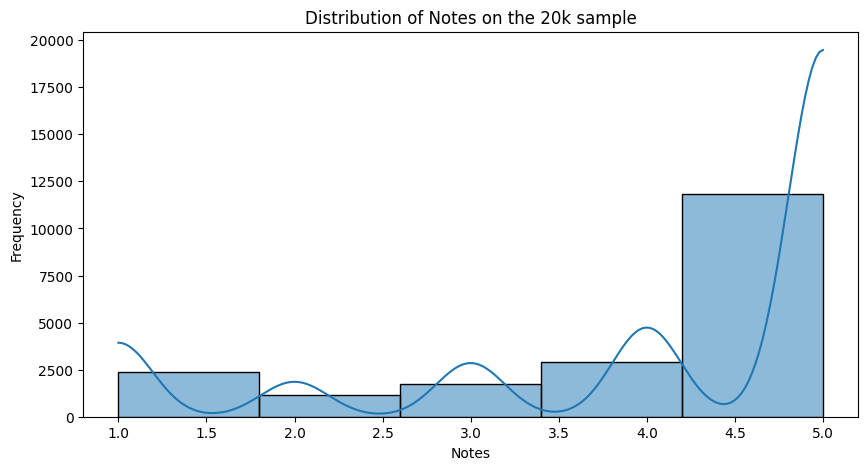

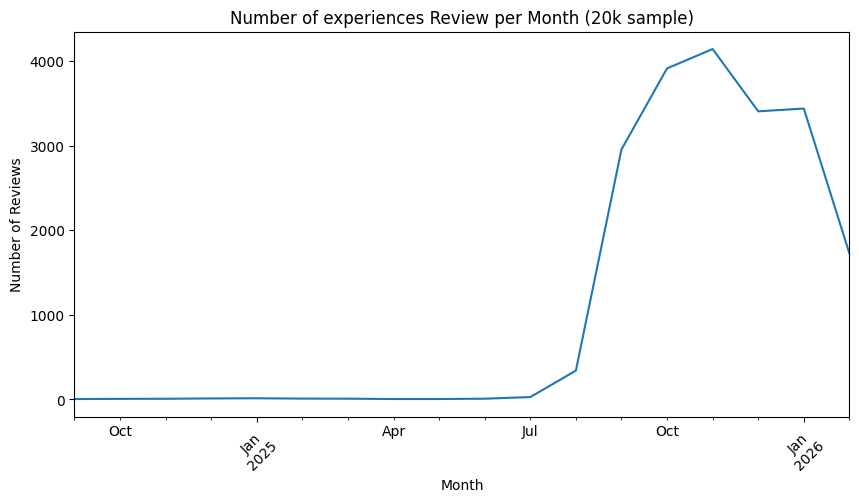

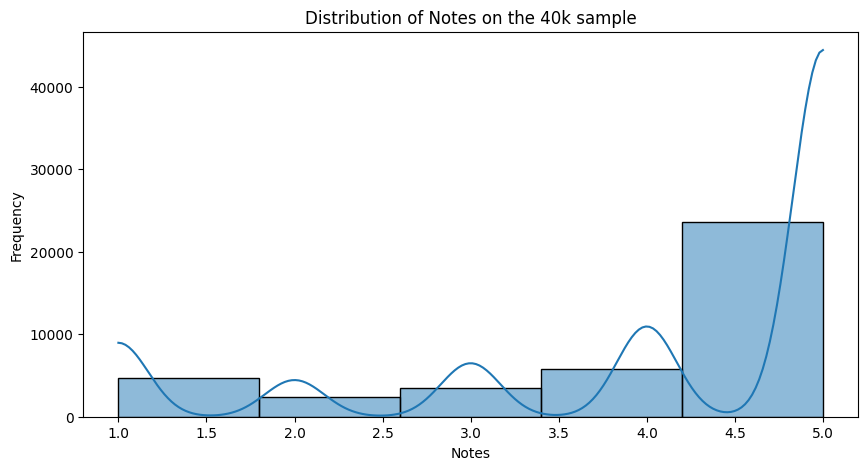

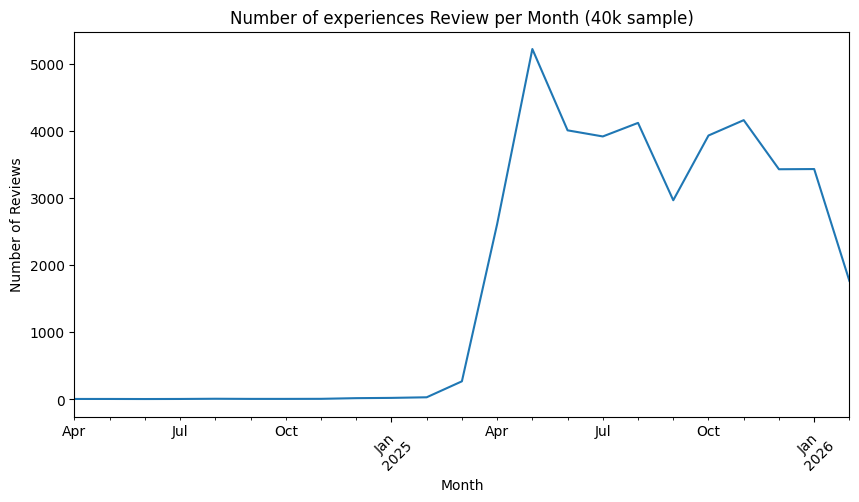

In [30]:
#two chart matplotlib one is a histogram of the distribution of the notes, the other is a time series of the number of reviews per month

# Histogram of the distribution of the notes
plt.figure(figsize=(10, 5))
sns.histplot(df20['rating'], bins=5, kde=True)
plt.title('Distribution of Notes on the 20k sample')
plt.xlabel('Notes')
plt.ylabel('Frequency')
plt.show()

# Time series of the number of reviews per month
monthly_reviews = df20.groupby('YearMonth_experience').size()
plt.figure(figsize=(10, 5))
monthly_reviews.plot(kind='line')
plt.title('Number of experiences Review per Month (20k sample)')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.show()

# Histogram of the distribution of the notes
plt.figure(figsize=(10, 5))
sns.histplot(df40['note'], bins=5, kde=True)
plt.title('Distribution of Notes on the 40k sample')
plt.xlabel('Notes')
plt.ylabel('Frequency')
plt.show()

# Time series of the number of reviews per month
monthly_reviews40 = df40.groupby('YearMonth_experience').size()
plt.figure(figsize=(10, 5))
monthly_reviews40.plot(kind='line')
plt.title('Number of experiences Review per Month (40k sample)')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.show()

La meilleur précision est fournit par Random Forest, le dernier model, 
qui semble etre le plus long à calculer (à vérifier) avec une accuracy de 0.96 sur le test

Sur les données Classifier charge_classe après la transformation on ne peut faire que de la classification
Bien sur avant la transformation sur charges_sum on pourait envisager des régressions, 
soit avec les régressions linéaires vue dans le cours 125, 
soit avec le pendant des classification qui sont également décliné en regression linéaire 
(respectivement, neighbors.KNeighborsRegressor, svm.SVR et ensemble.RandomForestRegressor)


## Vous ave dit WordCloud ??

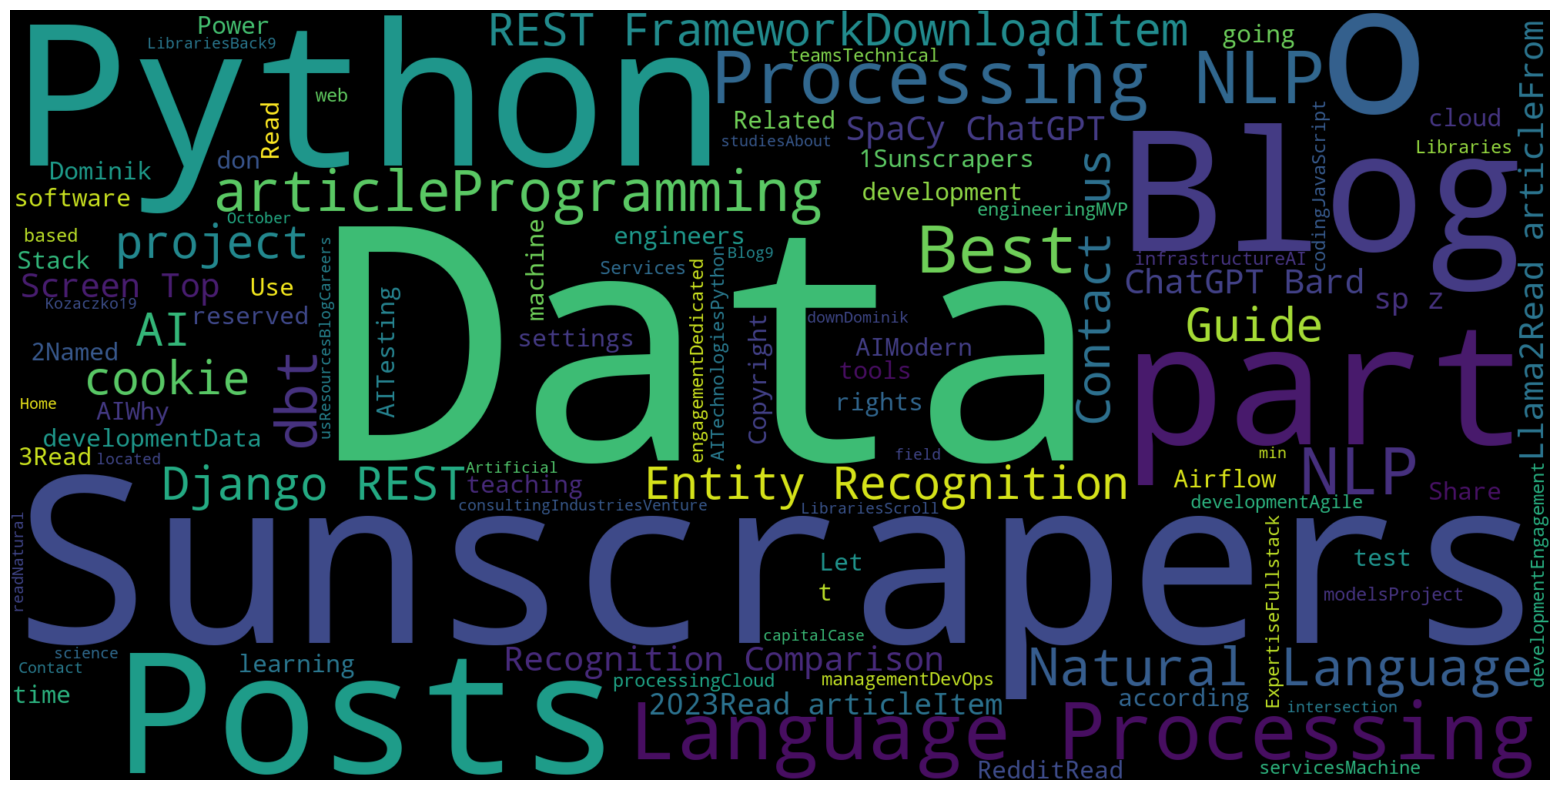

In [20]:

url ="https://sunscrapers.com/blog/9-best-python-natural-language-processing-nlp/index.html"
url="https://sunscrapers.com/blog/9-best-python-natural-language-processing-nlp/"

req = urllib.request.Request(url, headers={'User-Agent' : "Magic Browser"}) 
with urllib.request.urlopen(req) as response:
   html = response.read()

soup = bs4.BeautifulSoup(html, "html") # Extract the html
text = soup.get_text() # Extract the text from the html

if False:
  #Read text from a file 
  file=Path("data/avis_40k.csv")

  with open (file ,"r",encoding="utf-8") as file:
      text = file.read() 


# Create a WordC10ud object with customization 
wordcloud = WordCloud ( width = 2000
    , height=1000
    , background_color = "black" 
    , max_words = 100
    , colormap = "viridis"
    , contour_color = "black"
  ) . generate (text) 

# Display the word Cloud using Matplotlib 
plt.figure(figsize=(20, 10)) 
plt.imshow(wordcloud, interpolation = "bilinear") 
plt.axis("off") 
plt.show()


## mon sentiment sur Une première analyse de sentiments

0.0


,commentaire,polarity,subjectivity
0,"Produit conforme. La description du contenue est ambiguë car il faut 2 joints , sur la description il y a indiqué 2 mais en final reçu 1",-0.112500,0.325000
1,,0.000000,0.000000
2,..............R.A.S.........,0.000000,0.000000
3,,0.000000,0.000000
4,Tres bien mais attention bien scotcher les colis. Dernièrement j’ai reçu l’un d’eux ouvert !! Merci.,0.196094,0.225000
5,Piece conforme mais la gaine de protection sur la durite était abîmée( sans concéquence sur le bon fonctionnement),0.400000,0.425000
6,Very good experience.,0.000000,0.000000
7,,0.000000,0.000000
8,Prompt delivery,0.000000,0.000000
9,"Simple, rapide et efficace.",0.283333,0.300000


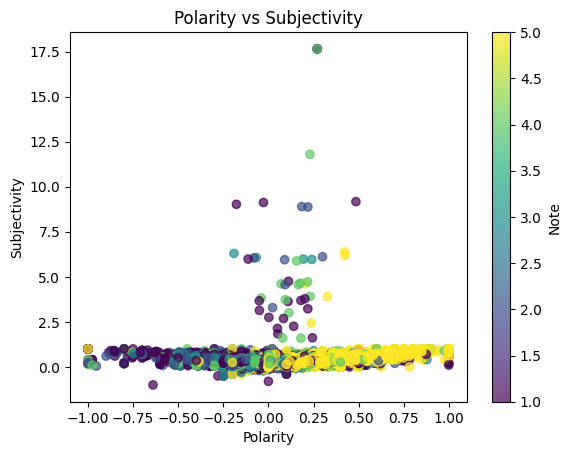

In [31]:
from textblob import TextBlob
from textblob_fr import PatternTagger, PatternAnalyzer

def get_polarity(blob):
    sentiment = blob.sentiment
    # Si c'est une liste ou un tuple (cas fréquent en FR)
    if isinstance(sentiment, (list, tuple)):
        return sentiment[0]
    # Si c'est l'objet nommé (cas classique EN)
    return getattr(sentiment, 'polarity', 0.0)

def get_ps_blob(blob):
    sentiment = blob.sentiment
    # Si c'est une liste ou un tuple (cas fréquent en FR)
    if isinstance(sentiment, (list, tuple)):
        return [sentiment[0], sentiment[1]]
    # Si c'est l'objet nommé (cas classique EN)
    return [getattr(sentiment, 'polarity', 0.0), getattr(sentiment, 'subjectivity', 0.0)]

text = "I definitely love to use this product. It's  very fantastic!"
#text = "I don't love this product. It's horrible!"
blob = TextBlob(text,pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())
sentiment = get_polarity(blob) #.sentiment.assessments #. .polarity
print(sentiment)
pd.options.display.max_rows = None

if True:
    df40small=df40.sample(1000, random_state=42)
    df40small=df40
    
df40small[["polarity","subjectivity"]] = df40small.apply(lambda x: get_ps_blob(TextBlob(str(x.commentaire),pos_tagger=PatternTagger(), analyzer=PatternAnalyzer()))
    , axis=1
    , result_type="expand")

display(df40small[["commentaire","polarity","subjectivity" ]].head(20))
plt.scatter(df40small["polarity"], df40small["subjectivity"], c=df40small["note"], cmap="viridis", alpha=0.7)
plt.title("Polarity vs Subjectivity")   
plt.xlabel("Polarity")
plt.ylabel("Subjectivity")  
plt.colorbar(label="Note")
plt.show()


## sarcasme: Polarité forte couplé à subjectivité faible

In [32]:
## sarcasme: Polarité forte couplé à subjectivité faible
df40small[(df40small.polarity < 1) & (df40small.subjectivity >1)][["commentaire","polarity","subjectivity","note"]]

,commentaire,polarity,subjectivity,note
1956,J'ai bien reçu mes colis en temps et en heure mais en ouvrant mes cartons la boite avec les plaquettes de freins avait déjà été ouverte et plein de graisse sur son emballage.,0.193333,5.983333,3
2229,"Pas assez de choix en relais colis alors qu'il y en a plein. D'être obligé de faire 60 km pour retirer un colis alors qu'il y a des relais à 10 km au plus loin autour de nous, c'est bien moyen tout çà !",0.109000,3.630000,1
2555,"Bon service, prix ok, livraison un peu lente... Une étoile en moins, surtout, pur cette enquête. Bientôt il y aura une enquête par plein d'essence ou même un passage au toilettes....",0.231000,3.910000,4
3077,je vous remercie de votre reponse surtout que des points relais il y en a plein autour de chez moi,0.270000,17.650000,2
3096,J'ai reçu les pièces mais les cartons emballages était plein eau,0.270000,17.650000,2
3649,Cette commande s'est bien passée et le délai de livraison a été respecté. J'ai enlevé une étoile car cette commande fait suite à un essuie-glace conducteur commandé en octobre 2025 chez Oscaro qui laisse une trainée de 5cm environ en plein milieu de mon champ de vision. J'espère que ce nouvel essuie-glace Valéo sera conforme.,0.094000,3.730000,4
4859,"Les pièces sont conformes à mes attentes, dommage que la livraison express soit payante plein tarif alors que vous proposer d'offrir la livraison normale !",0.070625,4.612500,4
5045,"Il faudrait passée un mot à vos livreurs et leur rappeler les principes de livraison à domicile. En plein tempête de pluie le livraison me jette le carton, dans lequel j'avais commandé un filtre à air et essuie-glace, dans le jardin. Il n'a même pas pris la peine de sonner ou d'appeler, heureusement que ce n'était pas un produit qui pouvait se détériorer avec la pluie, car il y est resté pendant des heures !",0.111250,4.750000,1
5385,"vue le marasme sociétale actuel? tout le reste de nos activités et besoin simplement exécuter en confiance et rigueur , ne son que ""petites"" satisfaction . continuer comme cela ( des possibilités de prix et le service) bonne année vous avec ce carton plein d'étoile ! agriculteur retraiter en colère du mépris irresponsable qui leur est imposer ? voila!",0.237812,2.431250,5
5948,Il a fallu que je passe 40 km allez retour pour récupérer colis pourtant ds mon village plein de relais je comprends pas pas content autodoc relais à 800 m de chez moi,-0.027500,9.125000,1


In [33]:
import subprocess
import sys
from textblob.exceptions import MissingCorpusError
from textblob import TextBlob
#répondre au "uv run python -m textblob.download_corpora -l fr"
try:
    TextBlob("test").tags
    print("Corpus déjà présent ✓")
except MissingCorpusError:
    print("Téléchargement des corpus...")
    #attention pour un corpus en français, il faut spécifier la langue -l fr, sinon c'est le corpus anglais qui est téléchargé par défaut
    subprocess.run([sys.executable, "-m", "textblob.download_corpora","-l","fr"], check=True)
    print("Corpus installés ✓")

Corpus déjà présent ✓


In [34]:
import sys
print(sys.getdefaultencoding())   # probablement 'utf-8'
import locale
print(locale.getpreferredencoding())  # probablement 'cp1252' ← le coupable

utf-8
cp1252


In [35]:
from textblob import TextBlob
from textblob_fr import PatternTagger, PatternAnalyzer
#

import unicodedata

def normalise_texte(texte):
    # Normalise les caractères unicode (apostrophes typographiques → droites, etc.)
    texte = unicodedata.normalize("NFKD", texte)
    # Réencode proprement en utf-8
    return texte.encode("utf-8", errors="ignore").decode("utf-8")

text="il fait vraiment vraiment vraiment" # très moche"
#text="Le filtre à huile préconisé sur le site au moment de l'achat ne correspond pas ,sur l'emballage il n'y figure pas , je dois racheter un filtre impossible de le visser à la clé un quart de tour celui qui correspond est le purflux LS717 et non le LS 716 je ne vais pas pouvoir le renvoyer à oscaro plein d'huile"

blob=TextBlob(normalise_texte(text),pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())

print(get_ps_blob(blob))

# On accède à l'analyse détaillée (le dictionnaire interne de Pattern)
# attention un "uv run python -m textblob.download_corpora" est due
# NE FONCTIONNE PAS POUR LE FRANÇAIS, il faut faire "uv run python -m textblob.download_corpora -l fr"
# et même comme ça, il y a des erreurs d'encodage à cause du lexique interne
# ce qui rend l'analyse détaillée difficile à exploiter, mais on peut quand même y accéder pour voir les mots et leur polarité
# comment faire pour corriger les erreurs d'encodage du lexique interne ?
# il faudrait peut-être essayer de faire une analyse plus fine en utilisant un autre lexique ou en corrigeant les erreurs d'encodage du lexique interne
# donc on essai
try:
    tags = blob.tags
    sentiment_detaille = blob.sentiment_assessments

    print("Score Global :", blob.sentiment)
    print("\n--- Détail par mot (Mot, Polarité, Subjectivité) ---")
    for assessment in sentiment_detaille.assessments:
        print(f"Mot(s): {assessment[0]} | Pol: {assessment[1]} | Subj: {assessment[2]}")

except (UnicodeDecodeError, TypeError) as e:
    print("Erreur d'encodage détectée au niveau du blob.tags:", e)
    



[0.0, 1.0]
Erreur d'encodage détectée au niveau du blob.tags: 'charmap' codec can't decode byte 0x9d in position 357: character maps to <undefined>


In [36]:
from textblob import TextBlob
from textblob_fr import PatternAnalyzer

try:
    # On teste un mot simple avec accent
    blob = TextBlob("Été", analyzer=PatternAnalyzer())
    print(blob.sentiment)
except UnicodeDecodeError as e:
    print(f"L'erreur vient bien du lexique interne : {e}")

(0.0, 0.0)


## petit exo kmeans avec init de centroids

5


,note,subjectivity,X
0,4,0.325,1
1,5,0.000,9
2,4,0.000,7
3,5,0.000,9
4,4,0.225,1
5,4,0.425,4
6,5,0.000,4
7,5,0.000,3
8,5,0.000,1
9,5,0.300,0


,note,subjectivity
X,,
0,4.082790,0.298663
1,4.013729,0.299332
2,4.034604,0.291531
3,4.007039,0.304444
4,4.039705,0.295637
5,4.052091,0.302612
6,4.000252,0.299642
7,3.980840,0.296857
8,4.040152,0.300421


,note,subjectivity,cluster
0,4,0.325,3
1,5,0.000,0
2,4,0.000,2
3,5,0.000,0
4,4,0.225,2


cluster
0    23567
7     7090
6     3435
2     3264
3     2528
5       30
9        6
4        2
1        1
8        1
Name: count, dtype: int64

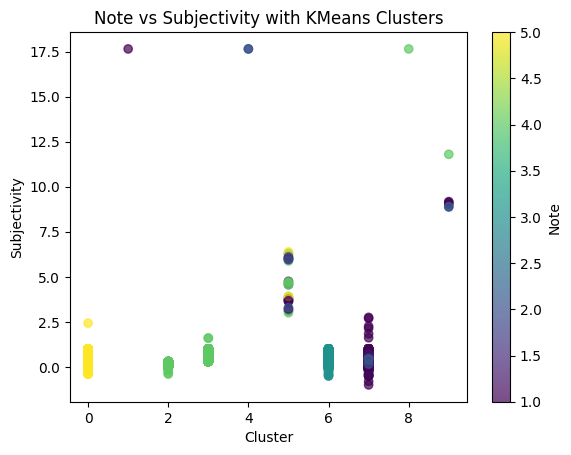

In [37]:

from sklearn.cluster import KMeans
from random import randrange

sv_data1 = df40small[[ "note", "subjectivity"]].copy()
print(randrange(10))

#def de clusters aléatoires pour tester la fonction de KMeans et initialiser les centroids
sv_data1["X"]=[ randrange(10) for x in sv_data1.index]    
display(sv_data1.head(10))

#"Centroid de chaque cluster"
display(sv_data1.select_dtypes(include=['number']).groupby("X").mean())
centroids_cah=sv_data1.select_dtypes(include=['number']).groupby("X").mean()
sv_data1.drop(columns=["X"], inplace=True)

#Kmeans avev initialisation des centroids à partir de la moyenne des clusters aléatoires
clf2 = KMeans(n_clusters=len(centroids_cah),random_state=42,init=centroids_cah.values)
clf2.fit(sv_data1)
kmeans2_predictions = clf2.predict(sv_data1)
kmeans2_predictions = clf2.labels_
#est la meme chose 
sv_data1["cluster"] = kmeans2_predictions

#on affiche la répartition des clusters par rapport à la classe de charge
#classes = pd.read_csv(Path("data/classes.csv"),sep=";")
#pd.crosstab(kmeans2_predictions, classes["type_classe"], rownames=["Cluster"], colnames=["Charge Classe"], margins=True)

display(sv_data1.head(),sv_data1.cluster.value_counts())
plt.scatter(sv_data1["cluster"], sv_data1["subjectivity"], c=sv_data1["note"], cmap="viridis", alpha=0.7)
plt.title("Note vs Subjectivity with KMeans Clusters")
plt.xlabel("Cluster")
plt.ylabel("Subjectivity")
plt.colorbar(label="Note")
plt.show()


## Le split par phrase

In [44]:
#at install time only " be carreful playing such game in multi env, please use the --active flag to ensure you are installing in the correct environment "
subprocess.run("uv run --active --with spacy spacy download fr_core_news_sm".split(" "), check=True)

CompletedProcess(args=['uv', 'run', '--active', '--with', 'spacy', 'spacy', 'download', 'fr_core_news_sm'], returncode=0)

In [45]:

# Chargement du modèle français
# prerequis : uv run --with spacy spacy download fr_core_news_sm (--with spacy pour installer dans l'environnement virtuel spacy au préalable)
# python -m ensurepip (si pip n'est pas installé correctement)
# uv run spacy download fr_core_news_sm

nlp = spacy.load("fr_core_news_sm")

def split_sentences_spacy(text):
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents]

# Exemple de données
df = pd.DataFrame({
    'idCommentaire': [1, 2],
    'commentaire': [
        "C'est génial ! Est-ce que ça marche ? Oui, m'dame.",
        "Le ML est fascinant. On adore Python."
    ]
})

# Application du split
df['Phrase'] = df['commentaire'].apply(split_sentences_spacy)

In [46]:
df

,idCommentaire,commentaire,Phrase
0,1,"C'est génial ! Est-ce que ça marche ? Oui, m'dame.","[C'est génial !, Est-ce que ça marche ?, Oui, m'dame.]"
1,2,Le ML est fascinant. On adore Python.,"[Le ML est fascinant., On adore Python.]"


In [47]:
# On "explose" la liste de phrases en plusieurs lignes
df_exploded = df.explode('Phrase').reset_index(drop=True)

# Création de l'idPhrase par groupe de commentaire
df_exploded['idPhrase'] = df_exploded.groupby('idCommentaire').cumcount() + 1

# Réorganisation des colonnes
df_final = df_exploded[['idCommentaire', 'idPhrase', 'Phrase']]

In [48]:
df_final

,idCommentaire,idPhrase,Phrase
0,1,1,C'est génial !
1,1,2,Est-ce que ça marche ?
2,1,3,"Oui, m'dame."
3,2,1,Le ML est fascinant.
4,2,2,On adore Python.


## 🟢 La fonction de split de préparation

In [49]:
#fonction de split par phase - qq choses prend 43 secondes ici
#structure du dataset de sortie, quelle caractéristique garder
#créer une idcommentaire sur le dataset de départ

nlp = spacy.load("fr_core_news_sm")

#fonction de split par phrase
def split_sentences_spacy(text):
    #testing text is not a Nan or empty string
    if pd.isna(text) or text.strip() == "":
        return []   
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents]

#fonction to speed up the split by phrase 
def split_sentences_spacy_fast(texts):
    #testing text is not a Nan or empty string
    # we can filter out the empty or NaN texts before processing to avoid unnecessary computations
    # but we need to keep track of the original indices to reassign the results correctly after processing
    # need to just replace with empty string instead of filtering out to keep the original indices
    texts = [text if not pd.isna(text) and text.strip() != "" else "" for text in texts]
    #texts = [text for text in texts if not pd.isna(text) and text.strip() != ""]
    docs = nlp.pipe(texts, disable=["ner", "tagger", "lemmatizer"])
    return [[sent.text.strip() for sent in doc.sents] for doc in docs]
#why is this faster ? because it processes the texts in batches and avoids the overhead of calling the nlp object for each text individually, 
# which can be time-consuming due to the loading of the model and the processing pipeline. 
# By using nlp.pipe, we can significantly reduce the processing time when dealing with large datasets.
#why do we disable ner, tagger and lemmatizer ? because we only need the sentence segmentation for our task, 
# and disabling these components can further speed up the processing by skipping unnecessary computations.
#how to use this function ? we can simply pass a list of texts to the split_sentences_spacy_fast function, and it will return a list of lists of sentences for each text.
# for example, if we have a dataframe df with a column 'commentaire', we can do:
# df['Phrase'] = split_sentences_spacy_fast(df['commentaire'].tolist())
# this will apply the fast splitting function to the 'commentaire' column and create a new column 'Phrase' with the list of sentences for each comment.
# we can also compare the processing time of the two functions to see the difference in speed, especially on larger datasets.

# import time
# start_time = time.time()
# df['Phrase'] = df['commentaire'].apply(split_sentences_spacy)
# print(f"Time taken with apply: {time.time() - start_time} seconds")
# start_time = time.time()
# df['Phrase'] = split_sentences_spacy_fast(df['commentaire'].tolist())
# print(f"Time taken with nlp.pipe: {time.time() - start_time} seconds")

# this will give us a clear comparison of the two methods and demonstrate the efficiency of using nlp.pipe for batch processing.
# in our case, since we are dealing with a large dataset of comments, using the split_sentences_spacy_fast function with nlp.pipe 
# will likely provide a significant performance improvement compared to the standard apply method.  

def main_split_prep(df,CommentCol='commentaire'):
    df = df.copy()
    df['idCommentaire'] = range(1, len(df) + 1)


    # start_time = time.time()
    df['Phrase'] = split_sentences_spacy_fast(df[CommentCol].tolist())
    # print(f"Time taken with nlp.pipe: {time.time() - start_time} seconds")

    # start_time = time.time()
    # df['Phrase'] = df[CommentCol].apply(split_sentences_spacy)
    # #df['Phrase'] = df['commentaire'].apply(split_sentences_spacy)
    # print(f"Time taken with apply: {time.time() - start_time} seconds")
    
    df_exploded = df.explode('Phrase').reset_index(drop=True)
    
    df_exploded['idPhrase'] = df_exploded.groupby(by='idCommentaire').cumcount() + 1
    if len(df_exploded) < 10:
        display(df_exploded)
    # joindre les colonnes de df à forwarder à df_exploded
    
    #if df_cols_to_forward:
    #    df_exploded = df[df_cols_to_forward].join(df_exploded[['idPhrase', 'Phrase']], on='idCommentaire')

    return df,df_exploded[['idCommentaire', 'idPhrase', 'Phrase']]
    

#auteur,note,titre,commentaire,
#df40.head()

## 🟢 💾 Préparation fichier de comments et de Phrases

In [54]:
#Splitting the comments into phrases and creating a new dataframe with idCommentaire, idPhrase, Phrase, Note
df40.head()

df40_comments,df40_phrases = main_split_prep(df40)

df40_comments.to_csv(Path("data/df40_comments.csv"), index=False, sep=";")
df40_phrases.to_csv(Path("data/df40_phrases.csv"), index=False, sep=";")
#OK en 30 secondes pour 40k commentaires, soit environ 0.75 seconde par 1000 commentaires, ce qui est très rapide pour du NLP en français avec spacy

#df40_phrases

### ▶➡️ Validation et analyse qualitative des résultats du split - exemple sur les 10 commentaires ayant le plus de phrases

In [3]:
#reprise et validation
df40_phrases = pd.read_csv(Path("data/df40_phrases.csv"),sep=";")
df40_comments = pd.read_csv(Path("data/df40_comments.csv"),sep=";")
display(df40_phrases.shape ,df40_comments.shape
 , df40_phrases.head(10) )

(80521, 3)

(39924, 17)

,idCommentaire,idPhrase,Phrase
0,1,1,Produit conforme.
1,1,2,"La description du contenue est ambiguë car il faut 2 joints , sur la description il y a indiqué 2 mais en final reçu 1"
2,2,1,NaN
3,3,1,..............R.A.S.........
4,4,1,NaN
5,5,1,Tres bien mais attention bien scotcher les colis.
6,5,2,Dernièrement j’ai reçu l’un d’eux ouvert !!
7,5,3,Merci.
8,6,1,Piece conforme mais la gaine de protection sur la durite était abîmée( sans concéquence sur le bon fonctionnement)
9,7,1,Very good


In [51]:
# stats sur le nombre de phrases par commentaire avec le top 10 des commentaires ayant le plus de phrases
df40_phrases_count = df40_phrases.groupby('idCommentaire').size().reset_index(name='nb_phrases')
top10 = df40_phrases_count.sort_values(by='nb_phrases', ascending=False).head(10)
display(top10)

,idCommentaire,nb_phrases
29506,29507,65
3409,3410,45
38656,38657,30
30796,30797,29
892,893,29
11424,11425,28
21705,21706,28
19623,19624,27
21934,21935,27
24366,24367,26


In [52]:
#selection des commentaires ayant le plus de phrases pour analyse qualitative
df40_top10_comments = df40_comments[df40_comments['idCommentaire'].isin(top10['idCommentaire'])]
df40_top10_comments 


auteur  note  \
892             Jason WEISS     1   
3409          Michel NGUYEN     1   
11424              DAVID Z.     1   
19623       Melaine Charles     1   
21705              Escpiere     1   
21934  Jose Folgado Gangoso     1   
24366                Daniel     1   
29506                Couzen     3   
30796              S. Meyer     1   
38656  jean philippe feraud     1   

                                                                               titre  \
892                                         Bonjour, Réclamation Commande A176429965   
3409   Attention a ce site qui vous vend des produits non conformes a votre véhicule   
11424                                               Je déconseille fortement ce site   
19623                                                   Ce fut une grosse déception.   
21705                                                Méfiez vous des frais de retour   
21934                                 Plazos de entrega falsos y mienten a sabiendas   
24366                                             17 jours et toujours pas d'envoi .   
29506                                       Ca ne s'arrange pas... ATTENTION a vous.   
30796                                             KEINE RÜCHERSTATTUNG für defektes…   
38656                                                                    Plus jamais   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

## Préparation de l'emmbedings

In [ ]:
# ne marche pas tout seul, => uv add sentence-transformers pour l'ajouter à l'environnement virtuel
# puis update jupyer et ipywidget with uv add -U jupyterlab ipywidgets

#MAIS ATTENTION ce modele est en anglais, il peut y avoir des problèmes de qualité sur du texte en français
#, il faudrait peut-être tester un modèle spécifiquement entraîné pour le français comme "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2" qui sont des modèles multilingues incluant le français, mais ils peuvent être moins performants que les modèles spécifiquement entraînés pour le français.
#pour illustration on prend d'abord celui-ci
#from sentence_transformers import SentenceTransformer
#model = SentenceTransformer('sentence-transformers/all-MiniLM-L12-v2')
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

print(df_final['Phrase'].tolist())
embeddings = model.encode(df_final['Phrase'].tolist())
print(embeddings)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


["C'est génial !", 'Est-ce que ça marche ?', "Oui, m'dame.", 'Le ML est fascinant.', 'On adore Python.']
[[-0.0493065   0.1769441   0.02980518 ...  0.03284987  0.08950894
  -0.06744152]
 [ 0.02595259  0.08993687 -0.00632736 ...  0.1193494   0.0106263
   0.0522471 ]
 [ 0.00715115  0.04406268 -0.02416156 ... -0.00731645  0.0488296
  -0.00484649]
 [-0.0006676   0.04229139 -0.07257052 ...  0.03425416  0.05930122
  -0.04666649]
 [-0.07043838 -0.02493281  0.02486094 ...  0.07520506  0.01770528
  -0.05542934]]


In [49]:
embeddings.shape ,df_final.shape, sys.getsizeof(embeddings)

((5, 384), (5, 3), 7808)

## estimation de l'espace mémoire de l'embedding

Une excellente habitude à prendre. En Machine Learning, on dit souvent que "Data is the new oil", mais la RAM est le moteur : si le moteur serre, plus rien ne bouge.

Voici une fonction Python élégante pour estimer la taille de vos embeddings avant et après leur création.

1. La fonction d'estimation (Predictive & Actual)
Cette fonction fait deux choses : elle estime la taille théorique (si vous ne les avez pas encore générés) et mesure la taille réelle (si l'objet existe déjà).

In [54]:
#un peu d'hygiène pour éviter la saturation de la mémoire
import numpy as np
#import sys

def estimate_ram_usage(n_samples, n_dimensions=384, dtype='float32', existing_array=None):
    """
    Estime ou mesure la consommation RAM d'un array NumPy d'embeddings.
    """
    # Tailles des types de données en octets
    bytes_map = {'float32': 4, 'float64': 8, 'float16': 2}
    
    if existing_array is not None:
        # Mesure réelle de l'objet en mémoire
        size_bytes = existing_array.nbytes
        n_samples, n_dimensions = existing_array.shape
    else:
        # Estimation théorique
        size_bytes = n_samples * n_dimensions * bytes_map.get(dtype, 4)

    # Conversion pour la lisibilité
    for unit in ['octets', 'Ko', 'Mo', 'Go']:
        if size_bytes < 1024.0:
            break
        size_bytes /= 1024.0
    
    print("📊 Rapport de RAM :")
    print(f"--- Configuration : {n_samples} phrases x {n_dimensions} dimensions")
    print(f"--- Consommation  : {size_bytes:.2f} {unit}")
    
    if unit == 'Go' and size_bytes > 8:
        print("⚠️ Attention : Risque de ralentissement sur une machine standard (8Go+).")

# --- Test de la fonction ---
# Simulation pour 500 000 phrases
estimate_ram_usage(n_samples=80000, n_dimensions=384, dtype='float32')

📊 Rapport de RAM :
--- Configuration : 80000 phrases x 384 dimensions
--- Consommation  : 117.19 Mo


2. Comprendre l'impact du Type de Donnée (dtype)
Le choix du dtype est votre levier principal pour éviter le crash. 
Voici un comparatif de ce que la même matrice d'embeddings (ex: 1 million de phrases) occupe selon la précision choisie :

| Précision | Type NumPy | Taille -1M phrases  |Usage recommandé|
|:--------- |:----------:| -------------------:|--------------------------------------------------|
| Haute     | float64    | 2.86 Go             | Calculs scientifiques ultra-précis (rare en NLP) |
| Standard  | float32    | 1.43 Go             | Défaut pour SentenceTransformers / Scikit-Learn  |
| Optimisée | float16    | 0.71 Go             | Stockage et réduction de dimension (UMAP/t-SNE)  |

3. Le piège de la "Matrice de Distance"
Il est crucial de noter que si vous utilisez des algorithmes comme t-SNE ou certains types de Clustering (Agglomerative), ils ne travaillent pas seulement sur vos vecteurs, mais créent une matrice de distance.Le calcul de cette matrice est de O(N^2).
- Pour 10 000 phrases, la matrice de distance occupe environ 400 Mo.
- Pour 100 000 phrases, elle grimpe à 40 Go !

C'est là que le débordement arrive, même si vos vecteurs originaux (les 1.43 Go mentionnés plus haut) semblaient passer sans problème.


## le bi-encoder (SentenceTransformer)

1. L'indépendance contextuelle (Bi-Encoder)Le modèle que vous utilisez (SentenceTransformer) est ce qu'on appelle un Bi-Encoder. Contrairement à un Chatbot (comme Claude / ChatGpt) qui lit tout votre historique pour répondre, le Bi-Encoder traite chaque phrase de manière isolée.
- Phrase A + Modèle X = Embedding unique $V_a$
- Peu importe que la Phrase A soit seule, dans une liste de 5 phrases ou noyée dans 1 million d'autres, son vecteur sera strictement identique.

2. Pourquoi est-ce une excellente nouvelle ?
Cette propriété mathématique a trois avantages majeurs pour votre projet :
  - 2.1 Mise en cache (Caching) : Vous pouvez sauvegarder vos embeddings dans une base de données. Si vous ajoutez de nouveaux commentaires demain, vous n'avez qu'à calculer les vecteurs des nouveaux arrivants.
  - 2.2 Parallélisation : Vous pouvez découper votre liste de 1 million de phrases en 10 morceaux et les envoyer à 10 processeurs différents ; le résultat final sera le même.
  - 2.3 Stabilité : Vos clusters et vos réductions de dimension resteront cohérents tant que vous ne changez pas de modèle.

3. Le bémol : Attention au changement de modèle
Si vous passez de all-MiniLM-L6-v2 (384 dim) à all-mpnet-base-v2 (768 dim) :
- Les vecteurs changent complètement.
- La dimension change.
- Vous devez tout recalculer. On ne peut pas "comparer" des vecteurs venant de deux modèles différents, car ils ne vivent pas dans le même espace vectoriel. C'est comme essayer de comparer une adresse en coordonnées GPS avec une adresse en code postal : elles désignent le même endroit, mais les chiffres n'ont rien à voir.

4. Sauvegarder pour ne plus payer le coût de calcul
Puisque les embeddings sont stables, voici la manière la plus "propre" de les stocker en Python avec NumPy pour éviter de solliciter votre CPU/GPU à chaque lancement :

In [64]:
embeddings.shape ,df_final.shape, sys.getsizeof(embeddings)


((5, 384), (5, 3), 128)

In [65]:
import numpy as np

# Sauvegarde binaire ultra-rapide
np.save('mes_5_embeddings.npy', embeddings)



In [66]:
# Recharge instantanée (plus besoin de lancer le modèle LLM !)
embeddings = np.load('mes_5_embeddings.npy')

Imaginez que vous ayez la phrase : "L'avocat est mûr".
Dans un Bi-Encoder classique, le vecteur sera le même que l'on parle d'un fruit ou d'un juriste, car le modèle n'a pas le contexte des phrases précédentes. C'est la seule limite de cette approche "phrase par phrase".

C'est le paradoxe classique du NLP : on veut de la granularité (spliter par phrase pour être précis) mais on ne veut pas perdre la substance (le contexte global du commentaire).

Si vous avez une phrase comme "Il est injoignable.", elle n'a pas la même valeur selon qu'elle suit "Le service client est nul" ou "Mon livreur est arrivé".

Voici les trois stratégies d'expert pour injecter du contexte sans sacrifier votre structure idCommentaire / idPhrase.

### 1. La stratégie "Le Petit Poucet" (Context Tagging)
C'est la méthode la plus simple et la plus robuste. Avant de générer l'embedding de la phrase, on lui attache un petit "rappel" du sujet global.

Le concept : Phrase_Finale = "Sujet du commentaire : " + Phrase

In [67]:
# Exemple de transformation -purement illustratif, ... Titre_Commentaire n'est pas défini ici
if False:
    df_exploded['Phrase_Contextuelle'] = "Contexte: " + df_exploded['Titre_Commentaire'] + " | Phrase: " + df_exploded['Phrase']

    # On encode ensuite cette nouvelle colonne
    embeddings = model.encode(df_exploded['Phrase_Contextuelle'].tolist())

Avantage : L'embedding de la phrase est "teinté" par le contexte global.

Inconvénient : Ça consomme quelques tokens de plus dans votre limite de 512 tokens du modèle.

### 2. La stratégie "Hybrid Embedding" (Le Best-of)
C'est l'approche la plus sophistiquée en Machine Learning. On crée deux embeddings et on les combine.

Vecteur A : L'embedding de la phrase seule (précision locale).

Vecteur B : L'embedding du commentaire complet (contexte global).

Fusion : On concatène ou on fait la moyenne des deux.

In [68]:
df

,idCommentaire,commentaire,Phrase
0,1,"C'est génial ! Est-ce que ça marche ? Oui, m'dame.","[C'est génial !, Est-ce que ça marche ?, Oui, m'dame.]"
1,2,Le ML est fascinant. On adore Python.,"[Le ML est fascinant., On adore Python.]"


In [69]:
# 1. On encode les commentaires complets (contexte)
if True:
    context_embeddings = model.encode(df['commentaire'].tolist()) # (n_comments, 384)

    # 2. On encode les phrases (local)
    phrase_embeddings = model.encode(df_exploded['Phrase'].tolist()) # (n_phrases, 384)

    # 3. Pour chaque phrase, on "injecte" un peu de son contexte parent
    # (C'est ici que l'idCommentaire est crucial pour mapper les deux)  



### 3. La stratégie "Fenêtre Glissante" (Sliding Window)
Si vos phrases sont très courtes, au lieu de les encoder isolément, vous encodez la phrase avec celle qui précède et celle qui suit.
- Entrée : [Phrase N-1] + [Phrase N] + [Phrase N+1]
- Sortie : Un vecteur qui sait d'où il vient et où il va.

Lequel choisir ?
|Besoin|Solution recommandée|
|-------|--------------------|
|Rapidité / Simplicité | Stratégie 1 (Concaténer un mot-clé ou le titre)|
|Haute Précision (Recherche) | Stratégie 2 (Vecteur Phrase + Vecteur Parent)|
|Analyse de Sentiment fine|Stratégie 3 (Fenêtre glissante)|

Commencez par la Stratégie 1. Si vos commentaires ont des titres (ex: "Déception totale", "Super produit"), 
ajoutez simplement le titre au début de chaque phrase avant l'encodage. 
C'est souvent suffisant pour lever 80% des ambiguïtés sans complexifier le code.

In [70]:
df_parent = df40_comments
df_phrases = df40_phrases
df_parent["commentaire"]=df_parent["commentaire"].fillna("") #remplace les NaN par des chaînes vides pour éviter les erreurs d'encodage
df_phrases["Phrase"]=df_phrases["Phrase"].fillna("") #remplace les NaN par des chaînes vides pour éviter les erreurs d'encodage

## the KISS 💋: un embeding simple sur les commentaires pour le moment

### Visualisation des tokens et conversion en pseudo syllabes 

### Analyse et detection des types de poids dans le model pour choisir sur quel type de hardware aller (CPU-GPU-NPU)
un site web https://netron.app/ ou on peut coller les modèles HF pour comprendre leur structure ou inspecter leur types
il faut ouvrir le fichier openvino_model.xml

Evidement, ouvrir des models privés n'est peu être pas vraiment approprié si le site collecte tout ce qu'on y regarde
si ce sont des models publiques, ok

La commande gagnante pour le téléchargement du model HF en conversion F32 vers F16 fut:

```bash
optimum-cli export openvino --model sentence-transformers/all-MiniLM-L12-v2 \
  --task feature-extraction --library sentence_transformers \
  --weight-format fp16 data/all-MiniLM-L12-v2-fp16/
# On prend ce dictionnaire multilingue ou les sentiments vont vectoriellement dans la même direction indépendament de la langue
optimum-cli export openvino --model sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 
  --task feature-extraction --library sentence_transformers 
  --weight-format fp16 data/PM-MiniLM-L12-v2-fp16/
```

In [ ]:
import openvino as ov
# intéressant, chargement du model seulement sur la base du seule fichier xml - à découvrir
core = ov.Core()
#model = core.read_model("./data/all-MiniLM-L12-v2-ov/openvino_model.xml")
#model = core.read_model("./data/all-MiniLM-L12-v2-fp16/openvino_model.xml")
model = core.read_model("./data/PM-MiniLM-L12-v2-fp16/openvino_model.xml")

# Vérifier le type de donnée des entrées
for input_node in model.inputs:
    print(f"Input '{input_node.any_name}': {input_node.get_element_type()}")

# Vérifier le type dominant dans les constantes (poids)
types = {op.get_element_type().get_type_name() for op in model.get_ops() if op.get_type_name() == "Constant"}
print(f"Types de données détectés dans les poids : {types}")

Input 'input_ids': <Type: 'int64_t'>
Input 'attention_mask': <Type: 'int64_t'>
Types de données détectés dans les poids : {'i64', 'f16', 'f32', 'i32'}


In [8]:
import openvino as ov

def get_ov_model_(model_path= "./data/all-MiniLM-L12-v2-fp16",xmlModelName="openvino_model.xml", batch_size=64, seq_length=128, ProcType="NPU"):
    from transformers import AutoTokenizer

    # 1. Charger le tokenizer (depuis votre dossier d'export)
    tokenizer = AutoTokenizer.from_pretrained(model_path)

    core = ov.Core()
    
    # Chargement du model depuis le xml file du dossier
    ov_model = core.read_model(model_path + "/" + xmlModelName)

    # On liste les vrais noms des inputs
    existing_inputs = [input.any_name for input in ov_model.inputs]
    print(f"Inputs réellement attendus par le modèle : {existing_inputs}")

    text="Dummy Initialization of the tokenizer with a sample sentence to see the input names and shapes."
    
    encoded_input = tokenizer(text, return_tensors="np", padding="max_length", max_length=128, truncation=True)
    
    # On définit des dimensions STATIQUES (Batch size = 64 (lignes), Sequence length = 128)
    # Cela évite l'erreur "Upper bounds not specified"
    myShape={ input_node.any_name:  [batch_size, seq_length] 
            for input_node in ov_model.inputs 
            if input_node.any_name in encoded_input
        }
    print("Reshaping",myShape)
    ov_model.reshape(myShape)

    print(f"Tentative de compilation sur le {ProcType} avec dimensions fixes...{batch_size} x {seq_length}")
    try:
        compiled_model = core.compile_model(ov_model, ProcType) #ProcType is "NPU" or "GPU" processor type if GPU we can go with batch size -1 to go any size
        print(f"✅ Succès ! Le {ProcType} accepte enfin le modèle statique.")
    except Exception as e:
        print("❌ Échec NPU persistant. Passage sur GPU Intel Arc...")
        compiled_model = core.compile_model(ov_model, "GPU")
        print("✅ Le GPU Intel Arc (120b) fonctionne parfaitement.")
    
    return compiled_model, core


def get_ov_model_1(model_path= "./data/all-MiniLM-L12-v2-fp16",xmlModelName="openvino_model.xml", batch_size=64, seq_length=128, ProcType="NPU"):
    from transformers import AutoTokenizer

    # 1. Charger le tokenizer (depuis votre dossier d'export)
    tokenizer = AutoTokenizer.from_pretrained(model_path)

    core = ov.Core()
    
    # Chargement du model depuis le xml file du dossier
    ov_model = core.read_model(model_path + "/" + xmlModelName)

    # On liste les vrais noms des inputs
    existing_inputs = [input.any_name for input in ov_model.inputs]
    print(f"Inputs réellement attendus par le modèle : {existing_inputs}")

    text="Dummy Initialization of the tokenizer with a sample sentence to see the input names and shapes."
    
    if ProcType == "CPU":
        encoded_input = tokenizer(text, return_tensors="np", padding="max_length", max_length=seq_length, truncation=True)
        configDict={"CACHE_DIR":"data/cpu_cache","PERFORMANCE_HINT": "THROUGHPUT"}

    if ProcType == "GPU":
        encoded_input = tokenizer(text, return_tensors="np", padding="max_length", max_length=128, truncation=True)
        configDict={"CACHE_DIR":"data/gpu_cache","PERFORMANCE_HINT": "THROUGHPUT"}

    if ProcType == "NPU":
        encoded_input = tokenizer(text, return_tensors="np", padding="max_length", max_length=128, truncation=True)
        configDict={"CACHE_DIR":"data/npu_cache","PERFORMANCE_HINT": "LATENCY"}
            
        
        encoded_input = tokenizer(text, return_tensors="np", padding="max_length", max_length=128, truncation=True)
        
    
    # On définit des dimensions STATIQUES (Batch size = 64 (lignes), Sequence length = 128)
    # Cela évite l'erreur "Upper bounds not specified"
    myShape={ input_node.any_name:  [batch_size, seq_length] for input_node in ov_model.inputs if input_node.any_name in encoded_input  }
    print("Reshaping",myShape)
    ov_model.reshape(myShape)

    print(f"Tentative de compilation sur le {ProcType} avec dimensions fixes...{batch_size} x {seq_length} et config {config}")

    try:
        compiled_model = core.compile_model(ov_model, ProcType) #ProcType is "NPU" or "GPU" processor type if GPU we can go with batch size -1 to go any size
        print(f"✅ Succès ! Le {ProcType} accepte enfin le modèle statique.")
    except Exception as e:
        print("❌ Échec NPU persistant. Passage sur GPU Intel Arc...")
        compiled_model = core.compile_model(ov_model, "GPU")
        print("✅ Le GPU Intel Arc (120b) fonctionne parfaitement.")
    
    return compiled_model, core
#compiled_NPU_model, core = get_ov_model_()

In [38]:
from transformers import AutoTokenizer
core = ov.Core()
model_path  , xmlModelName, batch_size, seq_length = "./data/PM-MiniLM-L12-v2-fp16" , "openvino_model.xml"  , 4, 128
# Chargement du model depuis le xml file du dossier
ov_model = core.read_model(model_path + "/" + xmlModelName)
# 1. Charger le tokenizer (depuis votre dossier d'export)
tokenizer = AutoTokenizer.from_pretrained("./data/PM-MiniLM-L12-v2-fp16")
encoded_input = tokenizer("bla blo bli", return_tensors="np", padding="max_length", max_length=128, truncation=True)
myShape={ input_node.any_name:  [batch_size, seq_length] for input_node in ov_model.inputs if input_node.any_name in encoded_input  }
print(encoded_input, myShape, sep="\n", end="\n\n")

encoded_input = tokenizer("bla blo bli", return_tensors="np", max_length=128, truncation=True)
myShape={ input_node.any_name:  [batch_size, seq_length] for input_node in ov_model.inputs if input_node.any_name in encoded_input  }
print(encoded_input, myShape, sep="\n", end="\n\n")

encoded_input = tokenizer("bla blo bli", return_tensors="np", padding=True, max_length=128, truncation=True)
myShape={ input_node.any_name:  [batch_size, seq_length] for input_node in ov_model.inputs if input_node.any_name in encoded_input  }
print(encoded_input, myShape, sep="\n", end="\n\n")

The tokenizer you are loading from './data/PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


{'input_ids': array([[    0,  9932, 29695,  2348,     2,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,

In [10]:
from openvino import Core
from transformers import AutoTokenizer
import numpy as np
from dataclasses import dataclass
import numpy as np

#a KISS for managing the structure of the output model, to allow having several at same time
@dataclass
class OVModel:
    compiled_model  : object
    tokenizer       : object
    batch_size      : int
    seq_length      : int
    padding         : object   # "max_length" ou True
    proc_type       : str
    input_names     : list[str]
    output_names    : list[str]


#same function purpose as the get_ov_model above
def load_model(model_path: str, xmlSrc: str, proc_type: str = "auto", batch_size: int = 16, seq_length: int = 128):
    """
    Charge et compile le modèle OpenVINO selon le procType.
    proc_type : "auto" | "gpu" | "npu" | "cpu"
    """
    core = Core()
    ov_model = core.read_model(f"{model_path}/{xmlSrc}")
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    #detection dynamique des inputs
    #Le NPU est particulièrement sensible aux inputs manquants — là où CPU/GPU peuvent parfois tolérer un input absent, le NPU crashe le kernel immédiatement.
    existing_inputs = [inp.any_name for inp in ov_model.inputs]

    # ── Résolution auto
    if proc_type == "auto":
        devices = [d.lower() for d in core.available_devices]
        if "npu" in devices:
            proc_type = "npu"
        elif "gpu" in devices:
            proc_type = "gpu"
        else:
            proc_type = "cpu"
        print(f"✓ Auto-détection → {proc_type.upper()}")

    # ── GPU — shape statique après reshape
    if proc_type == "gpu":
        #static declaration will make things fail or crash
        #v_model.reshape({ "input_ids":      [batch_size, seq_length], "attention_mask": [batch_size, seq_length] })
        #trying dynamic
        ov_model.reshape({name: [batch_size, seq_length] for name in existing_inputs})
        compiled_model = core.compile_model(ov_model, "GPU", config={ "CACHE_DIR": "data/gpu_cache", "PERFORMANCE_HINT": "THROUGHPUT" })
        padding      = "max_length"
        print(f"✓ GPU compilé — batch={batch_size}, seq={seq_length}")

    # ── NPU — shape statique obligatoire, batch petit
    elif proc_type == "npu":
        npu_batch = min(batch_size, 4)   # NPU préfère les petits batches
        ov_model.reshape({name: [batch_size, seq_length] for name in existing_inputs})
        compiled_model = core.compile_model(ov_model, "NPU", config={ "CACHE_DIR": "data/npu_cache", "PERFORMANCE_HINT": "LATENCY" })
        batch_size   = npu_batch
        padding      = "max_length"
        print(f"✓ NPU compilé — batch={npu_batch}, seq={seq_length} (compilation longue au 1er run)")

    # ── CPU — shape dynamique, pas de reshape
    elif proc_type == "cpu":
        compiled_model = core.compile_model( ov_model, "CPU", config={ "CACHE_DIR": "data/cpu_cache", "PERFORMANCE_HINT": "THROUGHPUT" })
        padding      = True   # dynamique — pad au plus long du batch
        print("✓ CPU compilé — shapes dynamiques")

    else:
        raise ValueError(f"proc_type inconnu : '{proc_type}' — utilisez 'gpu', 'npu', 'cpu' ou 'auto'") #pas encore de QPU ou de TPU ou de *PU
    
    #on prépare ici, au lieu de pendant l'usage, la création des deux structures input_names et output_names
    return OVModel(
        compiled_model  = compiled_model
        ,tokenizer      = tokenizer
        ,batch_size     = batch_size
        ,seq_length     = seq_length
        ,padding        = padding
        ,proc_type      = proc_type
        ,input_names    = [inp.any_name for inp in compiled_model.inputs]
        ,output_names   = [out.any_name for out in compiled_model.outputs]
    )



## temps de compilation d'un model 
Cela dépend de la taille du graphe - typiquement batch * séquence = 128 x 512 est dit énorme

Batch | Séquence | Temps compilation approx.
----- |----------|-------------------------- 
1     | 128      | ~10-30s
1     | 512      | ~30-60s
128   | 512      | ⏳ plusieurs minutes

## Différent usage NPU GPU CPU


Device       | Batch idéal | Séquence idéale | Usage et temps de compilation        
------------ | ----------- | --------------- | ----------------------------------- 
NPU          | 1 à 4       | 128             | latence faible  - requêtes unitaires 
GPU          | 8 à 32      | 128-512         | débit moyen                         
CPU OpenVINO | 16 à 64     | 512             | gros batch offline                  

Pourquoi le NPU est toujours statique
Le NPU Intel est un accélérateur matériel dédié — il compile les opérations en circuits logiques fixes à l'avance. Un shape variable nécessiterait une recompilation à chaque inférence, ce qui est impossible sur NPU. 

C'est pour ça qu'OpenVINO peut basculer silencieusement sur CPU quand on demande NPU avec un modèle à shapes dynamiques.

Le futur de tous ca  les ubuntu (1300 ingénieurs)
https://www.youtube.com/watch?v=0CYm-KCw7yY et l'architecture Inference Snap

les models par les vendeurs de silicon !! Tous les types de Processing Units
*PU CPU GPU NPU TPU QPU


In [9]:
#Usage NPU en latence faible, requetes unitaires batch idéal 
#Alors attention, pour que ca compile en NPU, il faut un batch_size p

compiled_NPU_model, core = get_ov_model_(model_path= "./data/PM-MiniLM-L12-v2-fp16"
  ,xmlModelName="openvino_model.xml"
  ,batch_size=3, seq_length=512, ProcType="NPU")

The tokenizer you are loading from './data/PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Inputs réellement attendus par le modèle : ['input_ids', 'attention_mask']
Reshaping {'input_ids': [3, 512], 'attention_mask': [3, 512]}
Tentative de compilation sur le NPU avec dimensions fixes...3 x 512
✅ Succès ! Le NPU accepte enfin le modèle statique.


In [ ]:
#Usage NPU en latence faible, requetes unitaires batch idéal 
#Alors attention, pour que ca compile en NPU, il faut un batch_size p

compiled_NPU_model1, core = get_ov_model_(model_path= "./data/PM-MiniLM-L12-v2-complet"
  ,xmlModelName="openvino/openvino_model.xml"
  ,batch_size=3, seq_length=512, ProcType="NPU")

  

Inputs réellement attendus par le modèle : ['input_ids', 'attention_mask', 'token_type_ids']
Reshaping {'input_ids': [3, 512], 'attention_mask': [3, 512], 'token_type_ids': [3, 512]}
Tentative de compilation sur le NPU avec dimensions fixes...3 x 512
✅ Succès ! Le NPU accepte enfin le modèle statique.


In [16]:
#compiled_NPU_model, core = get_ov_model_()
compiled_GPU_model, core = get_ov_model_(model_path= "./data/PM-MiniLM-L12-v2-fp16"
  ,xmlModelName="openvino_model.xml"
  ,batch_size=-1, seq_length=-1, ProcType="GPU")

The tokenizer you are loading from './data/PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Inputs réellement attendus par le modèle : ['input_ids', 'attention_mask']
Reshaping {'input_ids': [-1, -1], 'attention_mask': [-1, -1]}
Tentative de compilation sur le GPU avec dimensions fixes...-1 x -1
✅ Succès ! Le GPU accepte enfin le modèle statique.


In [17]:
def inputModelDetails(aCompiledModel):
    print(aCompiledModel.inputs)
    #[0].input_ids()

    for input in aCompiledModel.inputs:
        print(f"Nom    : {input.any_name}")
        print(f"Shape  : {input.partial_shape}")
        print(f"Type   : {input.element_type}")
        print(input  )

inputModelDetails (compiled_NPU_model)
inputModelDetails (compiled_GPU_model)      

[<ConstOutput: names[input_ids] shape[3,512] type: i64>, <ConstOutput: names[attention_mask] shape[3,512] type: i64>]
Nom    : input_ids
Shape  : [3,512]
Type   : <Type: 'int64_t'>
<ConstOutput: names[input_ids] shape[3,512] type: i64>
Nom    : attention_mask
Shape  : [3,512]
Type   : <Type: 'int64_t'>
<ConstOutput: names[attention_mask] shape[3,512] type: i64>
[<ConstOutput: names[input_ids] shape[?,?] type: i64>, <ConstOutput: names[attention_mask] shape[?,?] type: i64>]
Nom    : input_ids
Shape  : [?,?]
Type   : <Type: 'int64_t'>
<ConstOutput: names[input_ids] shape[?,?] type: i64>
Nom    : attention_mask
Shape  : [?,?]
Type   : <Type: 'int64_t'>
<ConstOutput: names[attention_mask] shape[?,?] type: i64>


In [12]:
def checkTokens(text,tokPath="./data/PM-MiniLM-L12-v2-fp16"):
    from transformers import AutoTokenizer
    # 1. Charger le tokenizer (depuis votre dossier d'export)
    tokenizer = AutoTokenizer.from_pretrained(tokPath)

    # 1. On récupère les IDs du dictionnaire (le tenseur [1, 128])

    encoded_input = tokenizer(text, return_tensors="np", padding="max_length", max_length=32, truncation=True )
    encoded_input = tokenizer(text, return_tensors="np", padding=True, truncation=True )
    print(encoded_input["input_ids"])
    
    # 2. On convertit les IDs en tokens textuels
    tokens_clair = tokenizer.convert_ids_to_tokens(encoded_input["input_ids"][0])

    # 3. Affichage propre (on enlève les tokens de bourrage [PAD])
    tokens_utiles = [t for t in tokens_clair if t != tokenizer.pad_token]

    print( "--- Visualisation du dictionnaire sémantique ---")
    print(f"Texte d'origine : {text}")
    print(f"Tokens envoyés au Backend (CPU/NPU/GPU) : {tokens_utiles}")
    print(f"Nombre de tokens réels : {len(tokens_utiles)}, on a enlevé les PAD")

checkTokens("""Bonjour madame, Bonjour Monsieur
            J'espère que vous vous portez bien
            """,tokPath="./data/PM-MiniLM-L12-v2-complet"  )

[[     0  84602  25248    282      4  84602 185830    821     25  55590
      41   1023   1023  23473    169   1806      2]]
--- Visualisation du dictionnaire sémantique ---
Texte d'origine : Bonjour madame, Bonjour Monsieur
            J'espère que vous vous portez bien
            
Tokens envoyés au Backend (CPU/NPU/GPU) : ['<s>', '▁Bonjour', '▁mada', 'me', ',', '▁Bonjour', '▁Monsieur', '▁J', "'", 'espère', '▁que', '▁vous', '▁vous', '▁porte', 'z', '▁bien', '</s>']
Nombre de tokens réels : 17, on a enlevé les PAD


## Encoddage large corpus de commentaires  
(et parking du backend sur GPU ou NPU - voir device) : 
En utilisant le modèle bas niveau avec size fix, batch_size optimisé pour les NPU Intel AI Boost,

Ici on se concentre sur le batching - attention à eventuellement rendre conditionnelle le padding à 512 token s'il n'y en a pas besoin en CPU ou GPU
le padding en NPU est obligatoire due à l'architecture du NPU, donc les cas d'usage colle pour des matrics de width connu (ou padded, mais limité).

In [13]:
import numpy as np, time
from transformers import AutoTokenizer
#https://docs.openvino.ai/2023.3/api/c_cpp_api/classov_1_1_compiled_model.html

def encode_large_corpus(model, texts, tokenizerpath="./data/all-MiniLM-L12-v2-fp16", batch_size=64,max_length=128):
    all_embeddings = []
    # 1. Charger le tokenizer (depuis votre dossier d'export)
    tokenizer = AutoTokenizer.from_pretrained(tokenizerpath)

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        num_texts = len(batch_texts)
        #print(i , i + batch_size, num_texts)
        vertical_padding_size = batch_size - num_texts
        #print(batch_texts)
        # Tokenisation du batch de batch_size
        encoded_input = tokenizer(
            batch_texts + [""] * vertical_padding_size,  # On ajoute des chaînes vides pour compléter le batch si besoin pour le dernier paquet
            padding="max_length", 
            max_length=max_length, 
            truncation=True, 
            return_tensors="np"
        )
        #print(encoded_input)
        # Filtrage chirurgical pour ne garder que les inputs attendus par le modèle compilé (des fois 3 ou ici 2)
        model_inputs = {
            input_node.any_name: encoded_input[input_node.any_name] 
            for input_node in model.inputs 
            if input_node.any_name in encoded_input
        }

        # Inférence application du modele sur l'input
        # Si vous utilisez le NPU statique, assurez-vous que batch_size 
        # est toujours identique au reshape !
        outputs = model(dict(model_inputs))
        
        #Dépendant de la manière dont on extrait les embeddings, soit on a obtenu un maxPooling à la volé pour une stucture en deux dim
        #soit on a extrait le model complet et on a une structure en 3D avec le pooling intermédiaire
        #ainsi un petit travail sur l'accés à la dimension de l'output et au calcul par meanpooling
        last_hidden_state = next(iter(outputs.values()))
        print(f"last_hidden_state : {last_hidden_state.shape}")  # → (3, 512, 384)

        if len( last_hidden_state ) == 3:
            # Mean pooling — moyenne sur les vrais tokens (ignore le padding)
            mask = encoded_input["attention_mask"][:, :, np.newaxis].astype(np.float32)
            # mask shape → (3, 512, 1)

            embeddings = (last_hidden_state * mask).sum(axis=1) / mask.sum(axis=1)
            # embeddings shape → (3, 384)  ← un vecteur par texte

        else:    
            # On récupère le 'sentence_embedding' (index 1 dans votre cas) dans le cas des extracts réalisé par optimum-cli
            embeddings = outputs[1][:num_texts]  # On ne garde que les embeddings correspondant aux textes réels (pas les padding du dernier batch)

        all_embeddings.append(embeddings)
        
        if i % 1000 == 0:
            print(f"Progression : {i}/{len(texts)} avis traités...")

    return np.vstack(all_embeddings)

#similaire à encode large corpuse bellow
def encode_batch(texts: list[str], m: OVModel) -> np.ndarray:
    """Encode une liste de textes en embeddings."""
    if not texts:
        return np.zeros((0, 384), dtype=np.float32)
    
    # ── Inputs attendus par ce modèle compilé sont retrouvé dans le dataclass passé en param    
    all_embeddings = []

    for i in range(0, len(texts), m.batch_size):
        batch = texts[i:i + m.batch_size]

        # Complète le batch si incomplet (obligatoire pour GPU/NPU statiques)
        padding_needed = m.batch_size - len(batch)
        batch_padded   = batch + [""] * padding_needed

        inputs = m.tokenizer( batch_padded, padding=m.padding, truncation=True, max_length=m.seq_length,  return_tensors="np"
            , return_token_type_ids=True,  # toujours demandé, ignoré si absent
            )
        
        #dynamo model inputs
        model_inputs = { name: inputs[name] for name in m.input_names if name in inputs }
        print(model_inputs)
        outputs = m.compiled_model(model_inputs)

        #mean pooling, ici suivant les formes vectories on peut avoir des token_vectors ou token_states, ou bien des embeddings
        raw_outputs = outputs[m.output_names[0]]  #was = next(iter(outputs.values())) that takes the first layer but is less robusts

        # ── Détection automatique selon le shape de sortie
        if raw_outputs.ndim == 3:
            # Modèle complet → (batch, seq, dim) → mean pooling nécessaire
            mask       = inputs["attention_mask"][:, :, np.newaxis].astype(np.float32)
            embeddings = (raw_outputs * mask).sum(axis=1) / mask.sum(axis=1)
        elif raw_outputs.ndim == 2:
            # Modèle fp16 optimum-cli → (batch, dim) → déjà poolé
            embeddings = raw_outputs
        else:
            raise ValueError(f"Shape de sortie inattendu : {raw_outputs.shape}")

        # Retire les embeddings de padding
        all_embeddings.append(embeddings[:len(batch)])

    return np.vstack(all_embeddings)





In [14]:
#Unit testing the complete method loading the model and embeding
# ── Usage
ov_npu = load_model(
    model_path = "data/PM-MiniLM-L12-v2-complet",    xmlSrc = "openvino/openvino_model.xml",
    #model_path = "data/PM-MiniLM-L12-v2-fp16",    xmlSrc = "openvino_model.xml",
    proc_type  = "npu",   # "gpu" | "npu" | "cpu" | "auto"
    batch_size = 3,
    seq_length = 512,
)

embeddings = encode_batch(["Le filtre ne correspond pas", "Très bon produit"] , ov_npu )

print(f"Embeddings shape : {embeddings.shape}")

✓ NPU compilé — batch=3, seq=512 (compilation longue au 1er run)
{'input_ids': array([[     0,    636,  80589, ...,      1,      1,      1],
       [     0, 103132,   3948, ...,      1,      1,      1],
       [     0,      2,      1, ...,      1,      1,      1]],
      shape=(3, 512)), 'attention_mask': array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0]], shape=(3, 512)), 'token_type_ids': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3, 512))}
Embeddings shape : (2, 384)


###  préparation de deux modèles en NPU et GPU

On prendra quelques records en taille de batch pour le traitement par lots sur NPU

On prendra un plus grand batch records en taille de batch pour le traitement par lots sur GPU

On essai de mettre en oeuvre le modèle complet

Voyons ici Quatre type de model, croissant deux models et deux backend différents


In [ ]:
#usage en fetch rapide dans une application, quelques records (max 4)
model_NPU_complet = load_model(
    model_path = "data/PM-MiniLM-L12-v2-complet",    xmlSrc = "openvino/openvino_model.xml",
    #model_path = "data/PM-MiniLM-L12-v2-fp16",    xmlSrc = "openvino_model.xml",
    proc_type  = "npu",   # "gpu" | "npu" | "cpu" | "auto"
    batch_size = 4,
    seq_length = 512,
)

#usage en batch médium
model_GPU_complet = load_model(
    model_path = "data/PM-MiniLM-L12-v2-complet",    xmlSrc = "openvino/openvino_model.xml",
    #model_path = "data/PM-MiniLM-L12-v2-fp16",    xmlSrc = "openvino_model.xml",
    proc_type  = "gpu",   # "gpu" | "npu" | "cpu" | "auto"
    batch_size = 64,
    seq_length = 512,
)

model_NPU_fp16 = load_model(
    #model_path = "data/PM-MiniLM-L12-v2-complet",    xmlSrc = "openvino/openvino_model.xml",
    model_path = "data/PM-MiniLM-L12-v2-fp16",    xmlSrc = "openvino_model.xml",
    proc_type  = "npu",   # "gpu" | "npu" | "cpu" | "auto"
    batch_size = 4,
    seq_length = 512,
)

model_GPU_fp16 = load_model(
    #model_path = "data/PM-MiniLM-L12-v2-complet",    xmlSrc = "openvino/openvino_model.xml",
    model_path = "data/PM-MiniLM-L12-v2-fp16",    xmlSrc = "openvino_model.xml",
    proc_type  = "npu",   # "gpu" | "npu" | "cpu" | "auto"
    batch_size = 64,
    seq_length = 512,
)

#usage en batch médium
modall_GPU_fp16 = load_model(
    #model_path = "data/PM-MiniLM-L12-v2-complet",    xmlSrc = "openvino/openvino_model.xml",
    model_path = "data/all-MiniLM-L12-v2-fp16",    xmlSrc = "openvino_model.xml",
    proc_type  = "gpu",   # "gpu" | "npu" | "cpu" | "auto"
    batch_size = 64,
    seq_length = 512,
)

modall_NPU_fp16 = load_model(
    #model_path = "data/PM-MiniLM-L12-v2-complet",    xmlSrc = "openvino/openvino_model.xml",
    model_path = "data/all-MiniLM-L12-v2-fp16",    xmlSrc = "openvino_model.xml",
    proc_type  = "npu",   # "gpu" | "npu" | "cpu" | "auto"
    batch_size = 4,
    seq_length = 512,
)

✓ NPU compilé — batch=4, seq=512 (compilation longue au 1er run)
✓ GPU compilé — batch=64, seq=512


The tokenizer you are loading from 'data/PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


✓ NPU compilé — batch=4, seq=512 (compilation longue au 1er run)


The tokenizer you are loading from 'data/PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


✓ GPU compilé — batch=64, seq=512


In [19]:
model_GPU_complet

OVModel(compiled_model=<CompiledModel:
inputs[
<ConstOutput: names[input_ids] shape[64,512] type: i64>,
<ConstOutput: names[attention_mask] shape[64,512] type: i64>,
<ConstOutput: names[token_type_ids] shape[64,512] type: i64>
]
outputs[
<ConstOutput: names[last_hidden_state] shape[64,512,384] type: f32>
]>, tokenizer=PreTrainedTokenizerFast(name_or_path='data/PM-MiniLM-L12-v2-complet', vocab_size=250002, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normal

Petite différence peinible entre l'accès au modèle complet et l'extract optimum cli avant.
# Modèle complet → 3 dimensions
print(next(iter(outputs_complet.values())).shape)   # → (batch, 512, 384)

# Modèle fp16 optimum-cli → 2 dimensions
print(next(iter(outputs_fp16.values())).shape)      # → (batch, 384) ✅ pooling inclus

si on extrait avec --task feature-extraction via le client Optimum, le meanPooling est fait à la volé, Et sinon il faut le faire impérativement, et nous même sinon il y a erreur d'execution sur les types manipulé.
A contrario on prendra soin si on a des données déjà meanPooler de ne pas appliquer l'opération sinon là encore, c'est faux

les fonctions de chargement de modèle doivent non seulement prendre en compte de manière dynamique les structure d'inputs et d'outputs
mais également détecter si lors d'une méthode de chargement, il y a eu un meanpooling en action pour calculer les embeddings (les incorporations de texte dans l'espace vectoriel)

## Étymologie du mot embedding
Le mot vient de l'anglais "to embed" — enchâsser, incruster, incorporer quelque chose dans un autre matériau.
Exemples concrets du mot anglais :

"a fossil embedded in rock" — un fossile enchâssé dans la roche
"an embedded journalist" — un journaliste intégré dans une unité militaire


Comment le mot est arrivé en mathématiques
En topologie et algèbre (années 1930-1950), une embedding désignait une injection continue d'un espace dans un autre — on "plonge" un espace de dimension inférieure dans un espace de dimension supérieure en préservant sa structure.
cercle (1D) → plongé dans → espace 3D
Le mot "plongement" est d'ailleurs la traduction mathématique française officielle.

L'arrivée en NLP et ML
Dans les années 2000-2010, les chercheurs en NLP ont repris ce terme pour décrire la même idée :
mot "chat"  →  plongé dans  →  espace vectoriel à 384 dimensions
   (discret)                        (continu)
Word2Vec (2013) a popularisé le terme — on "plonge" des mots discrets dans un espace vectoriel continu où les relations sémantiques deviennent des distances géométriques.

L'intuition profonde
Un embedding c'est fondamentalement une réponse à ce problème :
"chat", "chien", "voiture"
→ comment faire des maths avec des mots ?
→ on les plonge dans un espace numérique
  où "chat" et "chien" sont proches
  et "voiture" est loin

En français
Le mot "embedding" est utilisé tel quel dans la communauté française ML — la traduction officielle "plongement" existe mais est peu utilisée en pratique. Certains disent aussi "représentation vectorielle" ou "vecteur de représentation".

In [ ]:
# Utilisation Unit Testing, pensez à loader les imports et le dataset et compilé les models avant
if False:
    # avis_40000 = [...] # Votre liste d'avis
    # resultats = encode_large_corpus(compiled_model, tokenizer, avis_40000)
    df40_comments['commentaire']=df40_comments['commentaire'].fillna("")
    # En combinaison avec le get_ov_model_NPU() pour s'assurer que le modèle est bien chargé et compilé pour le NPU avant de lancer l'encodage en batch.

    nbavis=12890
    time_start = time.time()
    df40_comments_emb = encode_large_corpus(compiled_NPU_model, df40_comments['commentaire'].tolist(), tokenizerpath="./all-MiniLM-L12-v2-fp16", batch_size=64)
    print(f"Encodage terminé en {time.time() - time_start:.2f} secondes pour {len(df40_comments_emb)} avis.")
    #2 minutes et 20 secondes pour 40000 avis, ce qui est très rapide pour du NLP en français sur un NPU Intel AI Boost.

### 📖 Influence du dictionnaire Model de language sur la vectorization
sur HF il y a plus de 3 millions de models, bien choisir son modèle est important et quasiment infernal aussi.

Nombre de parametre, capacité de traitement, backend possible,

Initialement partant sur un MiniLM-L12-v2 on s'est rendu compte de l'influence linquistique, ce model n'étant pas French

Il existe des modèles multilingues qui envoit vectoriellement le sens des mots dans la même direction

Ici est l'illustration de ce phénomène. Nous encodons trois textes qui veulent dire la même chose dans trois langues différentes, 
et les modèles répondes différement suivant leur spécialité. Le modèle Paraphrase Multilingual va orienter les expressions vers le même endroit.

Tel que l'illustre les deux graphiques ci-dessous.

Attention, ce ne sont pas les identités des "tokens/Syllabes" qui compte, mais la projection dans l'espace vectorielle finale, c'est à dire les embedings (pas les tokenisations)




## 📈 Comparateur de vectorisation sur différent model pour différent backends

{'input_ids': array([[    0,    87,  5161, ...,     1,     1,     1],
       [    0,   845,   808, ...,     1,     1,     1],
       [    0,  1053, 48947, ...,     1,     1,     1],
       [    0,   654, 90163, ...,     1,     1,     1]], shape=(4, 512)), 'attention_mask': array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], shape=(4, 512)), 'token_type_ids': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4, 512))}
{'input_ids': array([[    0,    87,  5161, ...,     1,     1,     1],
       [    0,   845,   808, ...,     1,     1,     1],
       [    0,  1053, 48947, ...,     1,     1,     1],
       ...,
       [    0,     2,     1, ...,     1,     1,     1],
       [    0,     2,     1, ...,     1,     1,     1],
       [    0,     2,     1, ...,     1,     1,     1]], shape=(64, 512)), 'attention_mask': array([[1, 1, 1, 

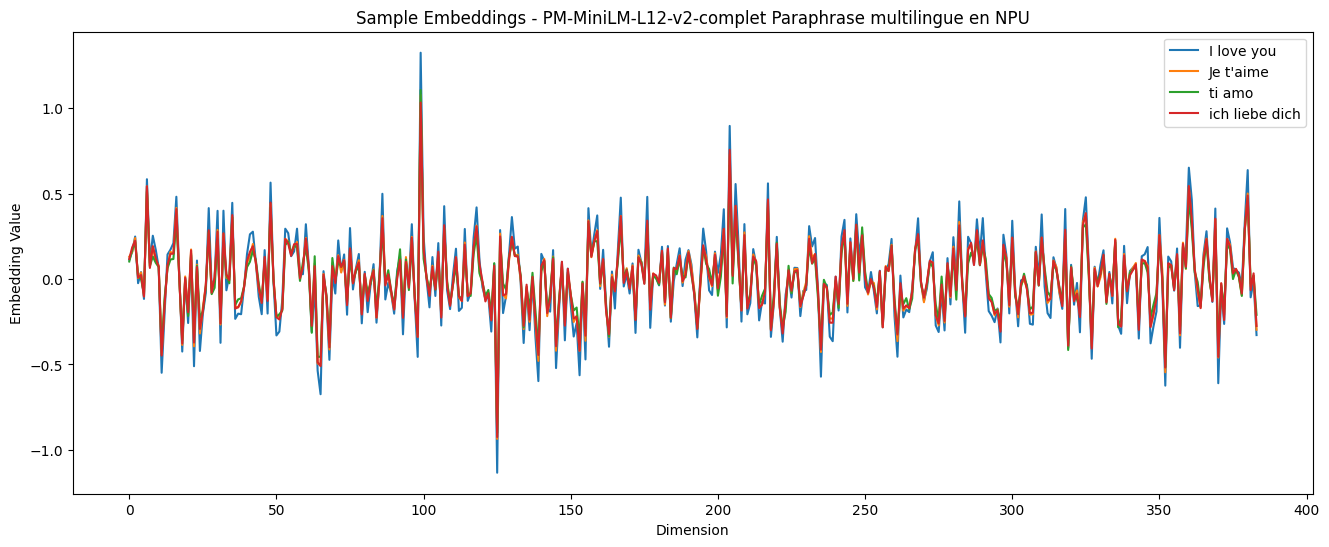

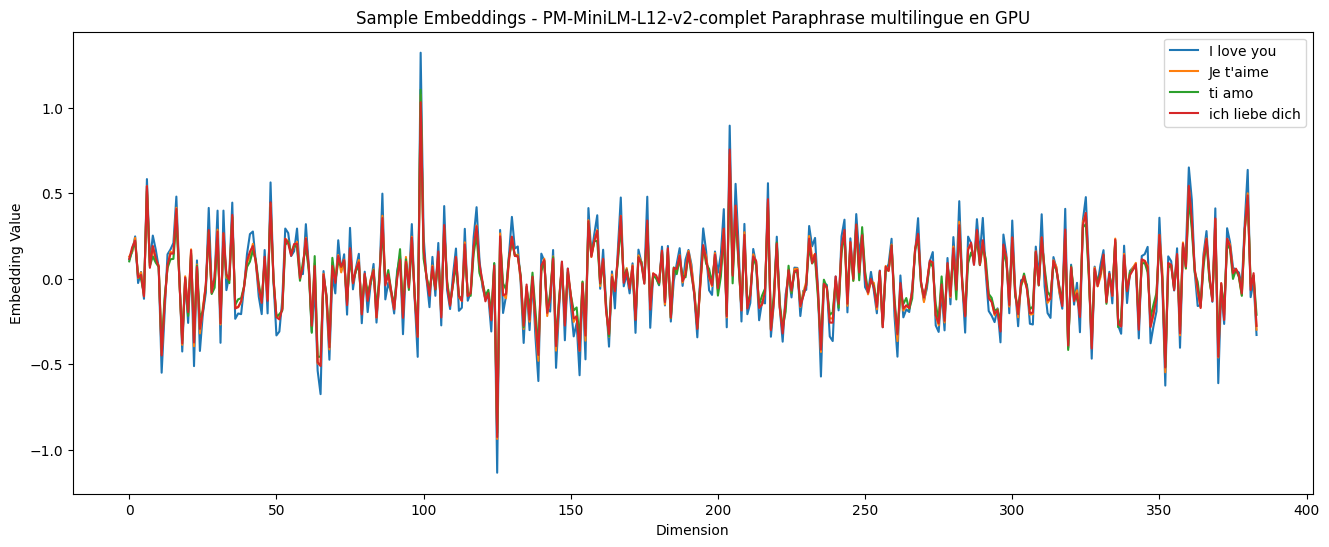

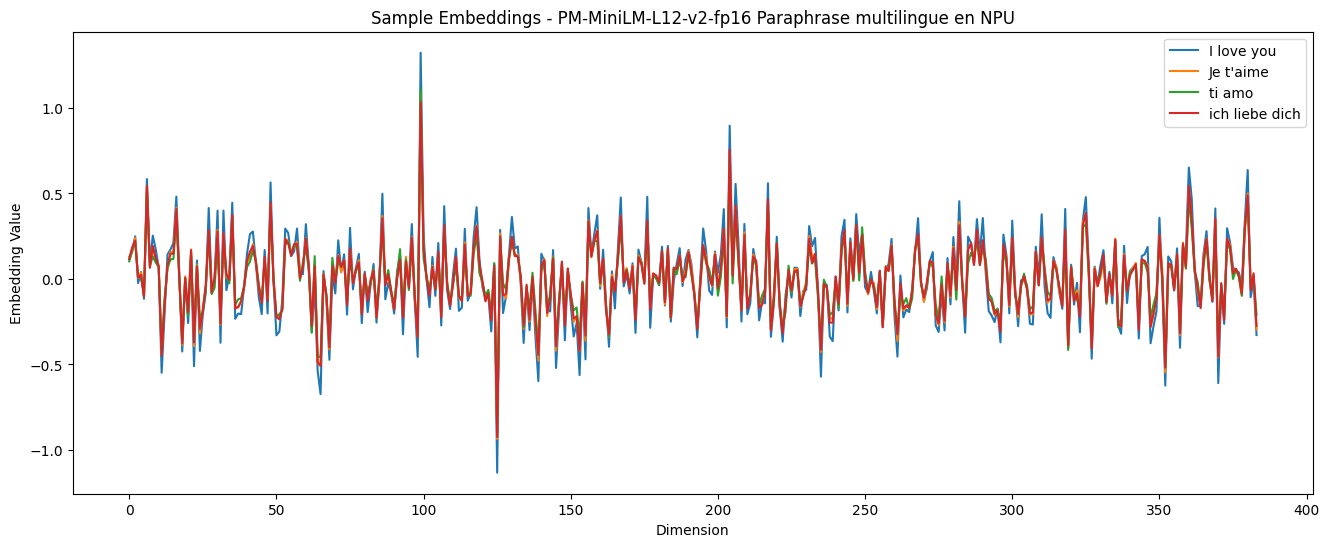

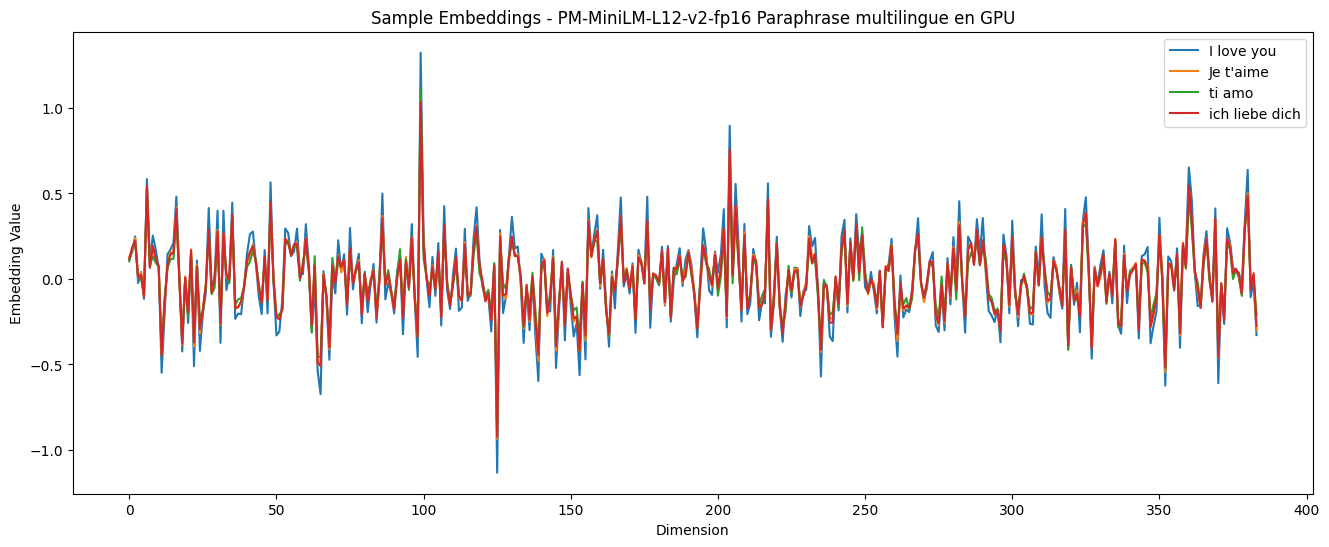

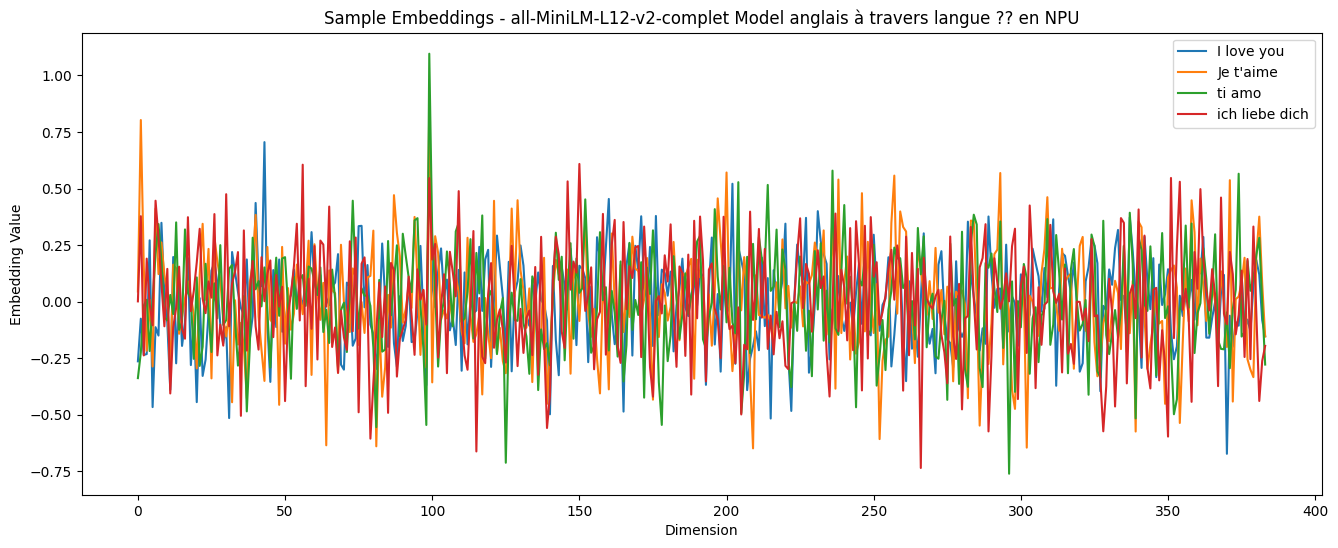

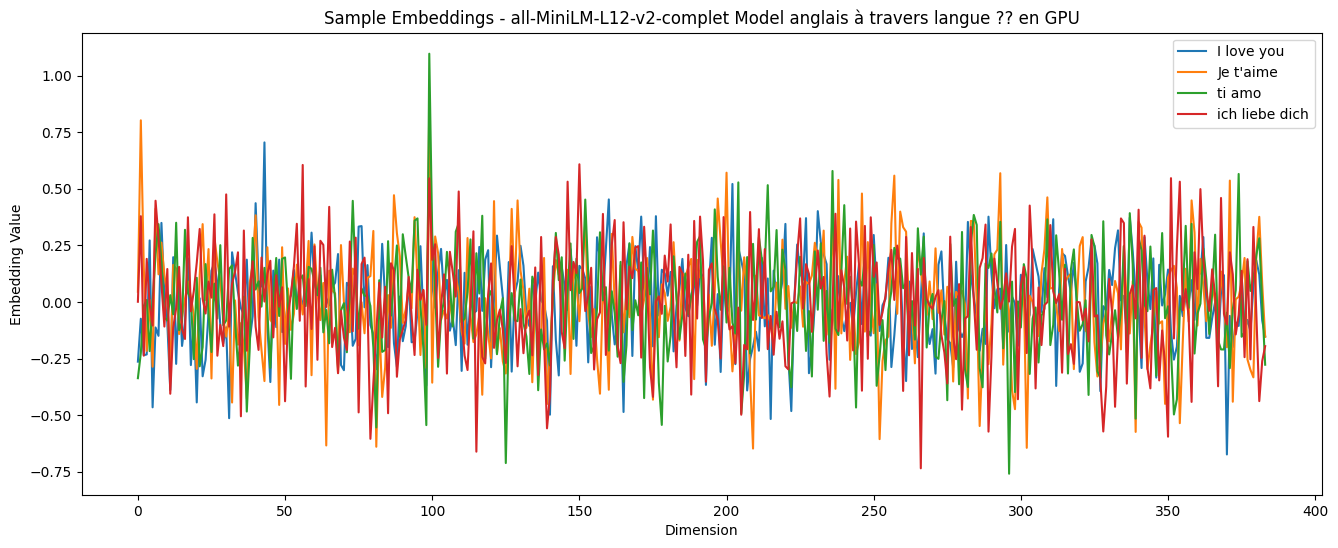

In [ ]:
#UNITESTING THE ENCODING FUNCTION WITH A SMALL SAMPLE
import matplotlib.pyplot as plt

def plotit(sample_texts,sample_embeddings,Title="Sample Embeddings"):
    fig, ax = plt.subplots(figsize=(16, 6))
    for i,txt in enumerate(sample_texts):
        plt.plot(sample_embeddings[i], label=txt)
    plt.xlabel("Dimension")
    plt.ylabel("Embedding Value")
    plt.title(Title)
    plt.legend()
    plt.show()


sample_texts = ["I love you","Je t'aime","ti amo", "ich liebe dich"]

#premieres expériences avec premiere encodage de large corpus par batch

if False:
    #sample_embeddings_all = encode_large_corpus(compiled_GPU_model, sample_texts, tokenizerpath=Path("./data/all-MiniLM-L12-v2-fp16"), batch_size=3, max_length=512)
    sample_embeddings_all = encode_large_corpus(compiled_NPU_model1, sample_texts, tokenizerpath=Path("./data/all-MiniLM-L12-v2-fp16"), batch_size=3, max_length=512)
    #sample_embeddings_PM = encode_large_corpus(compiled_GPU_model, sample_texts, tokenizerpath=Path("./data/PM-MiniLM-L12-v2-fp16"), batch_size=3, max_length=512)
    sample_embeddings_PM = encode_large_corpus(compiled_NPU_model1, sample_texts, tokenizerpath=Path("./data/PM-MiniLM-L12-v2-complet"), batch_size=3, max_length=512)
    plotit(sample_embeddings_all, Title="Sample Embeddings - all-MiniLM-L12-v2-fp16p multilingue peut-être mais surtout optimisé pour l'anglais")
    plotit(sample_embeddings_PM, Title="Sample Embeddings - PM-MiniLM-L12-v2-fp16 paraphrase multilingue optimisé pour toutes les langues")

#Rédaction alternative more robust encoding et distribution du load sur différent backend
#plusieurs objectifs, montrer la robustesse des embeddings accross backend et sources
sample_embeddings_PM_NPU_complet = encode_batch(sample_texts , model_NPU_complet )  
sample_embeddings_PM_GPU_complet = encode_batch(sample_texts , model_GPU_complet )
sample_embeddings_PM_NPU_fp16    = encode_batch(sample_texts , model_NPU_fp16 )
sample_embeddings_PM_GPU_fp16    = encode_batch(sample_texts , model_GPU_fp16 )
sample_embeddings_AL_NPU_fp16    = encode_batch(sample_texts , modall_NPU_fp16 )
sample_embeddings_AL_GPU_fp16    = encode_batch(sample_texts , modall_GPU_fp16 )


plotit(sample_texts, sample_embeddings_PM_NPU_complet, Title="Sample Embeddings - PM-MiniLM-L12-v2-complet Paraphrase multilingue en NPU")
plotit(sample_texts, sample_embeddings_PM_GPU_complet, Title="Sample Embeddings - PM-MiniLM-L12-v2-complet Paraphrase multilingue en GPU")
plotit(sample_texts, sample_embeddings_PM_NPU_fp16   , Title="Sample Embeddings - PM-MiniLM-L12-v2-fp16 Paraphrase multilingue en NPU")
plotit(sample_texts, sample_embeddings_PM_GPU_fp16   , Title="Sample Embeddings - PM-MiniLM-L12-v2-fp16 Paraphrase multilingue en GPU")
plotit(sample_texts, sample_embeddings_AL_NPU_fp16   , Title="Sample Embeddings - all-MiniLM-L12-v2-complet Model anglais à travers langue ?? en NPU")
plotit(sample_texts, sample_embeddings_AL_GPU_fp16   , Title="Sample Embeddings - all-MiniLM-L12-v2-complet Model anglais à travers langue ?? en GPU")




On peut voir l'exécution sur les deux cartes NPU 0 et GPU 0 dans le taks manager / Performance

<img src="./picts/NPU-GPU-in-action.png" alt="./picts/NPU-GPU-in-action.png" width="20%"/>

On a bien solicité notre GPU Intel Arc 140V et notre NPU AI Boost

In [ ]:
#Usage NPU en latence faible, requetes unitaires batch idéal 
#Alors attention, pour que ca compile en NPU, il faut un batch_size p

compiled_NPU_model, core = get_ov_model_(model_path= "./data/PM-MiniLM-L12-v2-fp16"
  ,xmlModelName="openvino_model.xml"
  ,batch_size=3, seq_length=512, ProcType="NPU")

The tokenizer you are loading from './data/PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Inputs réellement attendus par le modèle : ['input_ids', 'attention_mask']
Reshaping {'input_ids': [3, 512], 'attention_mask': [3, 512]}
Tentative de compilation sur le NPU avec dimensions fixes...3 x 512
✅ Succès ! Le NPU accepte enfin le modèle statique.


## 📈 Comparateur d'embeddings cross model

On constate l'effet du Paraphrase Multilingue, si on croise deux outputs qui veulent dire la même chose 

à travers langue, on est clairement plus linéaire en PM qu'en all pour les minilm models.

et par chance, notre approche multi backend répond stationnairement

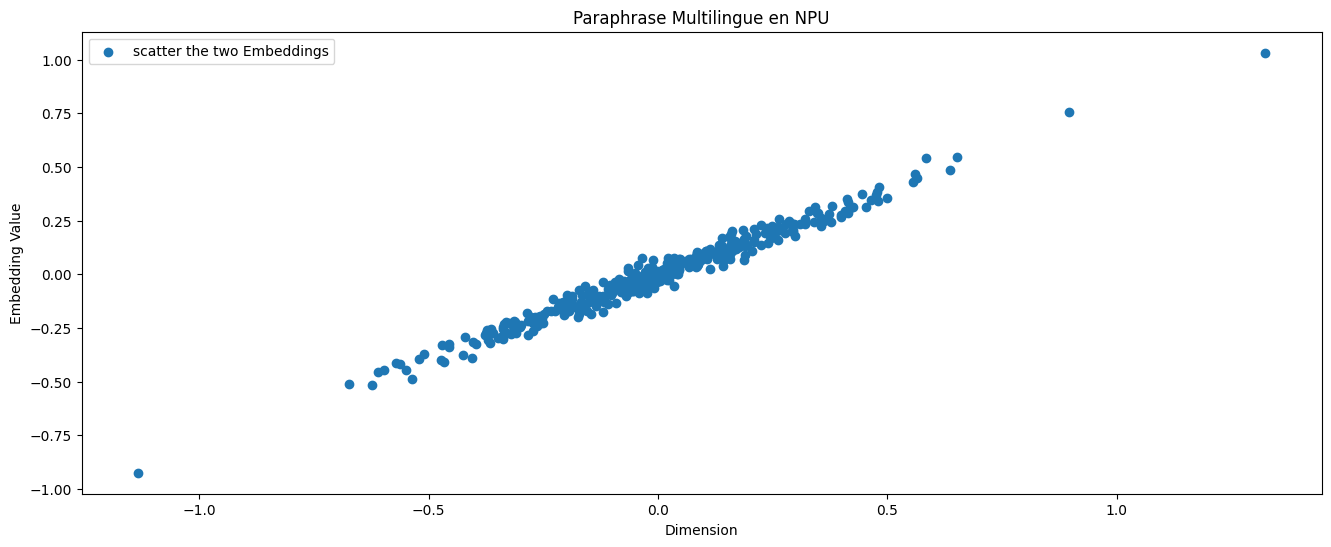

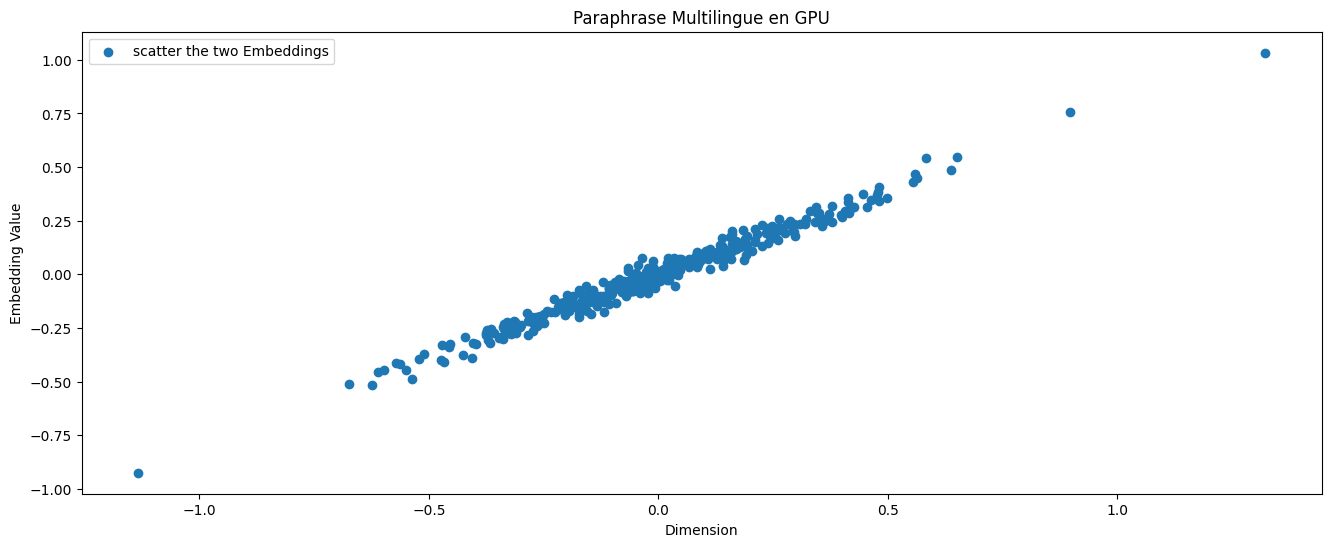

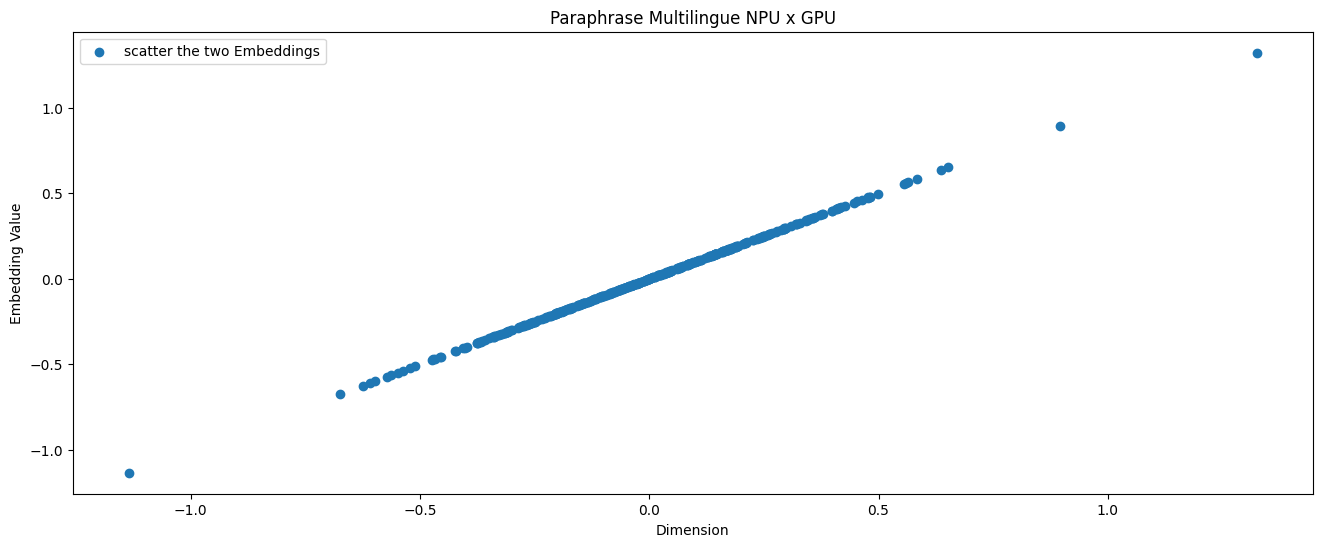

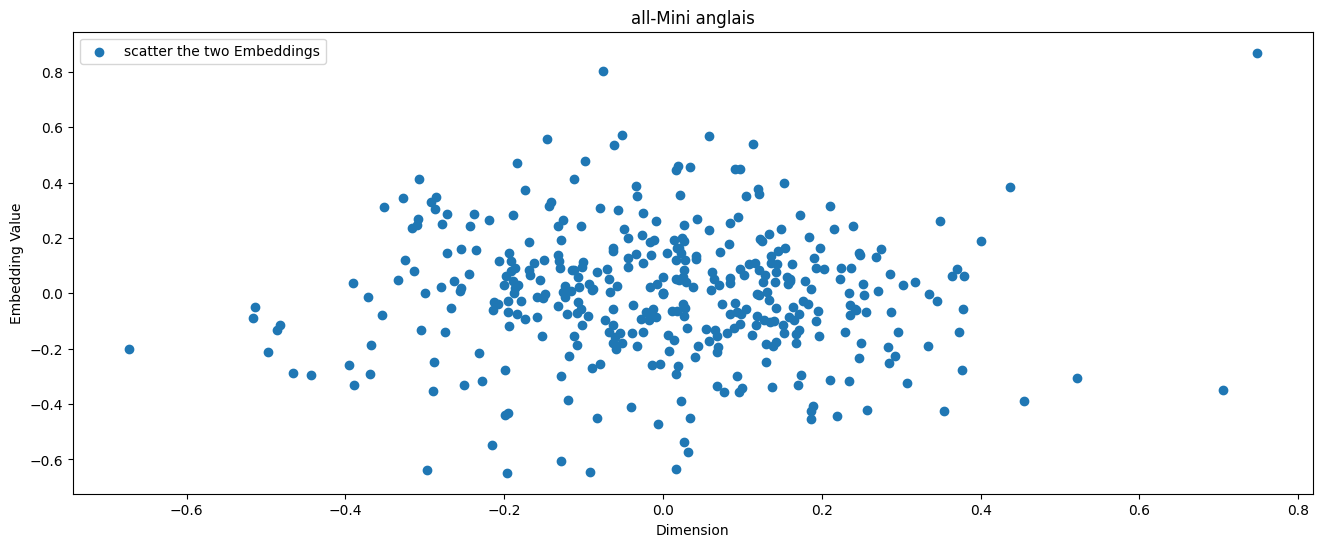

In [40]:
def diffit(sample_embeddings1, sample_embeddings2,Title="Comparison"):
    fig, ax = plt.subplots(figsize=(16, 6))
    #plt.plot(sample_embeddings1, label="Fist Embeding")
    #plt.plot(sample_embeddings2, label="Second Embeding")
    plt.scatter(sample_embeddings1,sample_embeddings2, label="scatter the two Embeddings")
    plt.xlabel("Dimension")
    plt.ylabel("Embedding Value")
    plt.title(Title)
    plt.legend()
    plt.show()

diffit(sample_embeddings_PM_NPU_complet[0],sample_embeddings_PM_NPU_complet[3],Title="Paraphrase Multilingue en NPU")
diffit(sample_embeddings_PM_GPU_complet[0],sample_embeddings_PM_GPU_complet[3],Title="Paraphrase Multilingue en GPU")
diffit(sample_embeddings_PM_NPU_complet[0],sample_embeddings_PM_GPU_complet[0],Title="Paraphrase Multilingue NPU x GPU")
diffit(sample_embeddings_AL_NPU_fp16[0],sample_embeddings_AL_NPU_fp16[1],Title="all-Mini anglais")

In [ ]:
#Ok attention au message buggy du début qui sert à rien
#mais sinon voici le patern
df40_comments_emb_GPU = encode_large_corpus(compiled_GPU_model,df40_comments['commentaire'].fillna("").head(1000).tolist()
  , tokenizerpath=Path("./data/PM-MiniLM-L12-v2-fp16"), batch_size=100, max_length=512)
#avec un pick en GPU


The tokenizer you are loading from 'data\PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Progression : 0/1000 avis traités...


In [23]:
#Ok attention au message buggy du début qui sert à rien
#mais sinon voici le patern
df40_comments_emb_NPU = encode_large_corpus(compiled_NPU_model,df40_comments['commentaire'].fillna("").head(1000).tolist()
  , tokenizerpath=Path("./data/PM-MiniLM-L12-v2-fp16"), batch_size=100, max_length=512)
#avec un pick en NPU


The tokenizer you are loading from 'data\PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Progression : 0/1000 avis traités...


## See the GPU encoding in action
You can capture the encoding action in the task manager Performance TAB in the GPU panel
you may select the Compute Frame Layout

<img src="./picts/gpu_pick.png" alt="./picts/gpu_pick.png" width="50%"/>

## encodage des 40000 avis en GPU
première et seconde approches


In [ ]:
#full Run
# bon alors choix, on passe en GPU, le NPU apportant une possible truncation, à voir !!

#Première approche
if False:
  df40_comments_emb_GPU = encode_large_corpus(compiled_GPU_model, df40_comments['commentaire'].tolist()
  , tokenizerpath="./data/PM-MiniLM-L12-v2-fp16", batch_size=100, max_length=512)

df40_comments_emb_NPU = encode_batch(df40_comments['commentaire'].tolist() , model_NPU_complet )    
df40_comments_emb_GPU = encode_batch(df40_comments['commentaire'].tolist() , model_GPU_complet )    

The tokenizer you are loading from './data/PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Progression : 0/39924 avis traités...
Progression : 1000/39924 avis traités...
Progression : 2000/39924 avis traités...
Progression : 3000/39924 avis traités...
Progression : 4000/39924 avis traités...
Progression : 5000/39924 avis traités...
Progression : 6000/39924 avis traités...
Progression : 7000/39924 avis traités...
Progression : 8000/39924 avis traités...
Progression : 9000/39924 avis traités...
Progression : 10000/39924 avis traités...
Progression : 11000/39924 avis traités...
Progression : 12000/39924 avis traités...
Progression : 13000/39924 avis traités...
Progression : 14000/39924 avis traités...
Progression : 15000/39924 avis traités...
Progression : 16000/39924 avis traités...
Progression : 17000/39924 avis traités...
Progression : 18000/39924 avis traités...
Progression : 19000/39924 avis traités...
Progression : 20000/39924 avis traités...
Progression : 21000/39924 avis traités...
Progression : 22000/39924 avis traités...
Progression : 23000/39924 avis traités...
Progr

### 💾Sauvegarde de l'embeddings pour aller en faire la classification

In [48]:
np.save(Path("data/df40_comments_embeddings_GPU.npy"), df40_comments_emb_GPU)

In [90]:
def PlotCompareEmbeding(emb0,lab0,emb1,lab1,Title="Sample Embeddings"):
    from sklearn.metrics.pairwise import cosine_similarity

    fig, ax = plt.subplots(figsize=(16, 6))
    plt.plot(emb0, label=lab0)
    plt.plot(emb1, label=lab1)
    plt.xlabel(f"{emb0.shape[0]} Dimensions")
    plt.ylabel("Embedding Value")
    plt.title(Title + f" (Cosine Similarity: {cosine_similarity(emb0.reshape(1, -1), emb1.reshape(1, -1))[0][0]:.4f})")
    plt.legend()
    plt.show()

## Estimation quand même du nombre d'avis tronqué par la méthode NPU

In [ ]:

def checkLengthIfTruncated(df,tokPath="./data/PM-MiniLM-L12-v2-fp16", seq_length = 512):
    from transformers import AutoTokenizer
    # 1. Charger le tokenizer (depuis votre dossier d'export)
    tokenizer = AutoTokenizer.from_pretrained(tokPath,)

    encoded_full = tokenizer(df.tolist(), truncation=False, padding=False)
    print(encoded_full['input_ids'] [:5])  # Affiche les IDs des 5 premiers avis sans tronquage
    # On calcule la longueur de chaque liste d'IDs
    lengths = [len(ids) for ids in encoded_full['input_ids']]

    # Analyse rapide
    
    nb_tronques = sum(1 for l in lengths if l > seq_length)
    mean_tronques = sum(l for l in lengths if l > seq_length)/nb_tronques
    pourcentage = (nb_tronques / len(avis_40000))

    print( "📊 Audit du Corpus :")
    print(f" - Avis tronqués (> {seq_length} tokens) : {nb_tronques}")
    print(f" - Taux de perte : {pourcentage:.2%}")
    print(f" - Longueur max réelle : {max(lengths)} et moyenne : {mean_tronques:.2f} tokens sur les gros")

checkLengthIfTruncated(df40_comments['commentaire'].fillna(""), seq_length = 512)

The tokenizer you are loading from './data/PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Token indices sequence length is longer than the specified maximum sequence length for this model (742 > 512). Running this sequence through the model will result in indexing errors


[[0, 51956, 217, 43739, 5, 239, 76811, 115, 59926, 13, 437, 920, 12282, 1025, 2258, 211, 9937, 116, 124416, 7, 6, 4, 613, 21, 76811, 211, 113, 10, 149841, 116, 732, 22, 2704, 84882, 106, 2], [0, 2], [0, 6, 5, 88125, 1052, 5, 284, 5, 294, 53106, 2], [0, 2], [0, 84790, 1806, 732, 35743, 1806, 14753, 18, 5372, 199, 3365, 164, 5, 1310, 164081, 674, 1647, 26, 508, 84882, 96, 26, 309, 104, 26, 10999, 90113, 6506, 26763, 5, 2]]
📊 Audit du Corpus :
 - Avis tronqués (> 512 tokens) : 20
 - Taux de perte : 0.05%
 - Longueur max réelle : 1222 et moyenne : 653.90 tokens sur les gros


## Caches OpenVINO — spécifiques à la machine, ne pas versionner

A propos de la gestion des caches - les caches c'est gros !! Notre petit projet consomme déjà 13GB en local - énorme pour un seul projet

Les models sont très gros comparé aux données à traiter.

Il y a des caches, vous avez vu, taille importante
à ne pas mettre sous github
ajouter dans le .gitignore


data/gpu_cache/
data/npu_cache/
data/cpu_cache/


A VOIR ULTERIEUREMENT LE CLEANING

Quand vider le cache

Situation	| Action
------------|-------------
Mise à jour d'OpenVINO	 | ✅ vider — format binaire incompatible
Changement de modèle	 | ✅ vider — hash différent, cache auto-invalidé
Changement batch_size ou seq_length	 | ✅ vider — paramètres de compilation différents
Mise à jour drivers GPU/NPU	 | ✅ vider — ABI potentiellement différente
Redémarrage normal	 | ❌ garder — le cache est encore valide
Comportement bizarre à l'inférence	 | ✅ vider — corruption possible

```
import shutil
from pathlib import Path

def clear_cache(proc_type: str = "all"):
    caches = {
        "gpu": Path("data/gpu_cache"),
        "npu": Path("data/npu_cache"),
        "cpu": Path("data/cpu_cache"),
    }

    targets = caches.values() if proc_type == "all" else [caches[proc_type]]

    for cache_dir in targets:
        if cache_dir.exists():
            shutil.rmtree(cache_dir)
            cache_dir.mkdir(parents=True)
            print(f"✓ Cache {cache_dir} vidé")
        else:
            print(f"⚠ Cache {cache_dir} inexistant")

# Usage
clear_cache("npu")   # vide uniquement le cache NPU
clear_cache("all")   # vide tous les caches
```


```
@dataclass
class OVModel:
    ...
    cache_dir : Path | None   # None si cache désactivé

# Permet de vider proprement depuis l'objet
def clear_model_cache(ov: OVModel):
    if ov.cache_dir and ov.cache_dir.exists():
        shutil.rmtree(ov.cache_dir)
        ov.cache_dir.mkdir(parents=True)
        print(f"✓ Cache {ov.cache_dir} vidé")

        ```

In [41]:
import shutil
from pathlib import Path
from openvino import Core
import openvino as ov

def diagnostic_cache():
    core            = Core()
    devices_dispo   = [d.lower() for d in core.available_devices]
    ov_version      = ov.__version__

    print(f"OpenVINO version    : {ov_version}")
    print(f"Devices disponibles : {devices_dispo}")
    print()

    caches = {
        "cpu": Path("data/cpu_cache"),
        "gpu": Path("data/gpu_cache"),
        "npu": Path("data/npu_cache"),
    }

    for device, cache_dir in caches.items():
        if not cache_dir.exists():
            print(f"  {device.upper()} : aucun cache")
            continue

        # Taille du cache
        taille = sum(f.stat().st_size for f in cache_dir.rglob("*") if f.is_file())
        nb     = len(list(cache_dir.rglob("*.blob")))

        # Device disponible ?
        dispo  = device in devices_dispo

        statut = "✅ actif" if dispo else "🗑 inutile — device absent"
        print(f"  {device.upper()} : {statut}")
        print(f"    {nb} blob(s) — {taille / 1024**2:.1f} MB")
        print(f"    chemin : {cache_dir}")

        if not dispo:
            print(f"    → recommandation : clear_cache('{device}')")
        print()

diagnostic_cache()

OpenVINO version    : 2026.0.0-20965-c6d6a13a886-releases/2026/0
Devices disponibles : ['cpu', 'gpu', 'npu']

  CPU : ✅ actif
    2 blob(s) — 673.6 MB
    chemin : data\cpu_cache

  GPU : ✅ actif
    7 blob(s) — 1545.8 MB
    chemin : data\gpu_cache

  NPU : ✅ actif
    6 blob(s) — 1415.6 MB
    chemin : data\npu_cache



In [43]:
from pathlib import Path
from datetime import datetime
import json

def list_cache_blobs():
    caches = {
        "cpu": Path("data/cpu_cache"),
        "gpu": Path("data/gpu_cache"),
        "npu": Path("data/npu_cache"),
    }

    core            = Core()
    devices_dispo   = [d.lower() for d in core.available_devices]

    for device, cache_dir in caches.items():
        if not cache_dir.exists():
            print(f"\n── {device.upper()} : aucun cache")
            continue

        blobs = list(cache_dir.rglob("*.blob"))
        if not blobs:
            print(f"\n── {device.upper()} : dossier vide")
            continue

        print(f"\n── {device.upper()} ({'actif' if device in devices_dispo else '⚠ device absent'})")
        print(f"   {len(blobs)} blob(s)")

        for blob in sorted(blobs, key=lambda f: f.stat().st_mtime):
            taille = blob.stat().st_size / 1024**2
            mtime  = datetime.fromtimestamp(blob.stat().st_mtime)
            print(f"   {blob.name[:16]}...  {taille:6.1f} MB  modifié : {mtime:%Y-%m-%d %H:%M}")

            # Cherche le json de métadonnées associé
            meta = blob.with_suffix(".json")
            if meta.exists():
                try:
                    data = json.loads(meta.read_text())
                    print(f"     → {data}")
                except Exception:
                    pass

list_cache_blobs()


── CPU (actif)
   2 blob(s)
   1654971541288140...   448.8 MB  modifié : 2026-03-22 18:30
   8214829897262162...   224.8 MB  modifié : 2026-03-22 18:34

── GPU (actif)
   7 blob(s)
   6572932234282010...   226.9 MB  modifié : 2026-03-22 21:11
   1115145391917850...   230.2 MB  modifié : 2026-03-22 21:11
   1021444876163523...   229.9 MB  modifié : 2026-03-22 21:12
   1697467943903866...   229.8 MB  modifié : 2026-03-22 21:15
   6147143223427246...   230.0 MB  modifié : 2026-03-22 23:01
   4698954478365780...   277.6 MB  modifié : 2026-03-22 23:58
   1383556028423066...   117.1 MB  modifié : 2026-03-23 00:03

── NPU (actif)
   6 blob(s)
   3898321908867922...   229.3 MB  modifié : 2026-03-22 21:15
   5332876974682527...   262.3 MB  modifié : 2026-03-22 22:06
   1258301658080604...   262.2 MB  modifié : 2026-03-22 22:39
   6621991146816377...   274.1 MB  modifié : 2026-03-22 23:01
   8378647077016881...   274.2 MB  modifié : 2026-03-22 23:58
   1348206824732207...   113.5 MB  modifié : 

## La clusterisation, regroupement de nos avis


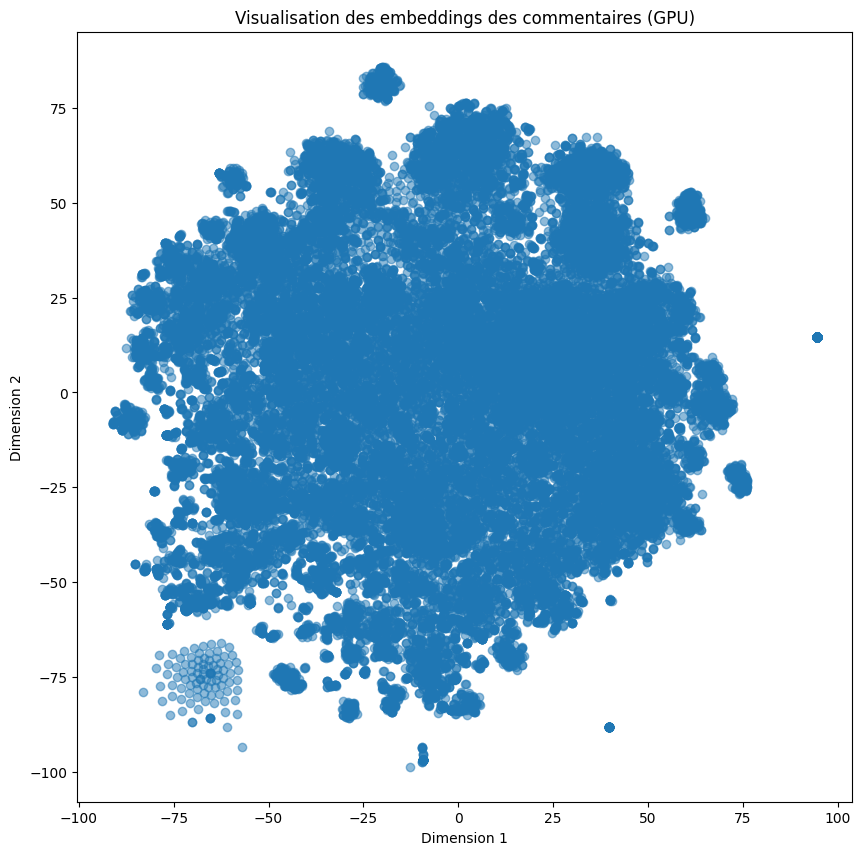

In [49]:
#embeddings est un tableau numpy de dimension (nombre de phrases, dimension de l'embedding)
# on peut faire une réduction de dimension pour visualiser les embeddings, par exemple avec t-SNE ou PCA
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)

#load the embeddings from the GPU encoding for visualization
df40_comments_emb_GPU = np.load(Path("data/df40_comments_embeddings_GPU.npy"))

embeddings_2d = tsne.fit_transform(df40_comments_emb_GPU)
plt.figure(figsize=(10, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5)
plt.title("Visualisation des embeddings des commentaires (GPU)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


## De la géométrie à la sémantique

passer de la géométrie (des points dans un espace) à la sémantique (des mots métier compréhensibles). 
Une fois que vos phrases sont regroupées par UMAP + Clustering (comme HDBSCAN ou K-Means), vous avez des groupes, mais ils sont "muets".

Pour extraire les mentions les plus significatives, l'approche de référence en NLP moderne est le c-TF-IDF (Class-based TF-IDF).

La logique :

Vous regroupez toutes les phrases du Cluster 1 dans un seul grand texte.

Vous faites de même pour le Cluster 2, etc.

Vous calculez le score TF-IDF de chaque mot, où chaque "document" est en fait un cluster.

Les mots avec le score le plus élevé dans le Cluster 1 sont ceux qui apparaissent beaucoup ici, mais très peu ailleurs. Ce sont vos "mentions significatives".



### 1. La méthode reine : c-TF-IDF
Le TF-IDF classique cherche les mots importants dans un document. Le c-TF-IDF cherche les mots qui distinguent un groupe de commentaires par rapport aux autres groupes.

La logique :

Vous regroupez toutes les phrases du Cluster 1 dans un seul grand texte.

Vous faites de même pour le Cluster 2, etc.

Vous calculez le score TF-IDF de chaque mot, où chaque "document" est en fait un cluster.

Les mots avec le score le plus élevé dans le Cluster 1 sont ceux qui apparaissent beaucoup ici, mais très peu ailleurs. Ce sont vos "mentions significatives".

### 2. Implémentation en Python (Le Workflow)
Voici comment extraire ces mots-clés métier après votre réduction de dimension.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. On prépare les données : on regroupe les phrases par cluster
# On suppose que df_final a une colonne 'cluster' issue de votre clustering
docs_per_cluster = df_final.groupby('cluster')['Phrase'].apply(lambda x: ' '.join(x)).reset_index()

# 2. Application du TF-IDF sur ces "super-documents"
tfidf_model = TfidfVectorizer(stop_words='french', ngram_range=(1, 2)) 
# ngram_range(1,2) permet de capturer "service client" ou "delai livraison"
tfidf_matrix = tfidf_model.fit_transform(docs_per_cluster['Phrase'])

# 3. Extraction des top mots par cluster
words = tfidf_model.get_feature_names_out()
for i, row in docs_per_cluster.iterrows():
    cluster_id = row['cluster']
    # Récupérer les scores pour ce cluster
    scores = tfidf_matrix.getrow(i).toarray().flatten()
    # Trier les indices des meilleurs scores
    top_indices = scores.argsort()[-5:][::-1] # Top 5 mots
    
    print(f"Cluster {cluster_id} - Thématique : {[words[idx] for idx in top_indices]}")

### 3. Aller plus loin : L'approche par "Centroïde"

Si vous voulez trouver la phrase exacte (la mention) la plus représentative :

Calculez le centroïde de votre cluster (la moyenne de tous les vecteurs du groupe).

Cherchez la phrase dont l'embedding est le plus proche de ce centroïde (distance cosinus minimale).

Cette phrase est votre "médaille d'or" : c'est elle qui résume le mieux le topic métier.

### 4. Conseils métier pour la catégorisation

Stop-words personnalisés : En entreprise, certains mots sont partout (ex: le nom de votre boîte). 
Ajoutez-les à votre liste de stop_words pour qu'ils ne polluent pas vos clusters.

Les N-grammes : Ne vous limitez pas aux mots seuls. "Livraison" c'est bien, "Livraison domicile" c'est un topic métier.

Le filtrage POS (Part-of-Speech) : Souvent, seuls les Noms et les Adjectifs portent le sens métier. 
Vous pouvez utiliser spaCy pour ne garder que ces types de mots avant de faire le c-TF-IDF.

### Petite digression de subplot

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# 1. Configuration de la figure (figsize doit être grand pour 100 images)
fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for k in range(100):
    # Calcul des coordonnées dans la grille 10x10
    row = k // 10
    col = k % 10
    
    ax = axes[row, col]
    
    # --- Simulation d'une image (remplacez par vos données) ---
    img = np.random.rand(28, 28) 
    #img = X[k].values.reshape(28,28)
    ax.imshow(img)#, cmap='viridis')
    # ---------------------------------------------------------
    
    # Nettoyage pour l'esthétique
    ax.set_title(f"Id:{k}", fontsize=8)
    ax.axis('off') 

# Ajustement automatique des espacements
plt.tight_layout()
plt.show()
;


## 1. Méthode "Zéro-Shot" (La plus rapide, sans entraînement)
Utiliser la Similarité Cosinus par rapport à des "ancres" (des topics d'intérêt).

Définissez des centres d'intérêt (ex: "Délais", "Emballage", "Service Client", "Prix").
list of 11 Topics to embed


Computation of the topics embedding

Encodez ces mots-clés avec le même modèle (GPU).

Calculez la distance entre chaque avis et chaque mot-clé.

In [103]:
lstTopics=["livraison", "delivery service","order", "commande","product","price","prix","quality","service","mistake","warranty","website","refund"]
df11_topics_embeddings = encode_large_corpus(compiled_GPU_model, lstTopics, tokenizerpath=Path("./data/PM-MiniLM-L12-v2-fp16"), batch_size=20, max_length=512)

The tokenizer you are loading from 'data\PM-MiniLM-L12-v2-fp16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Progression : 0/13 avis traités...


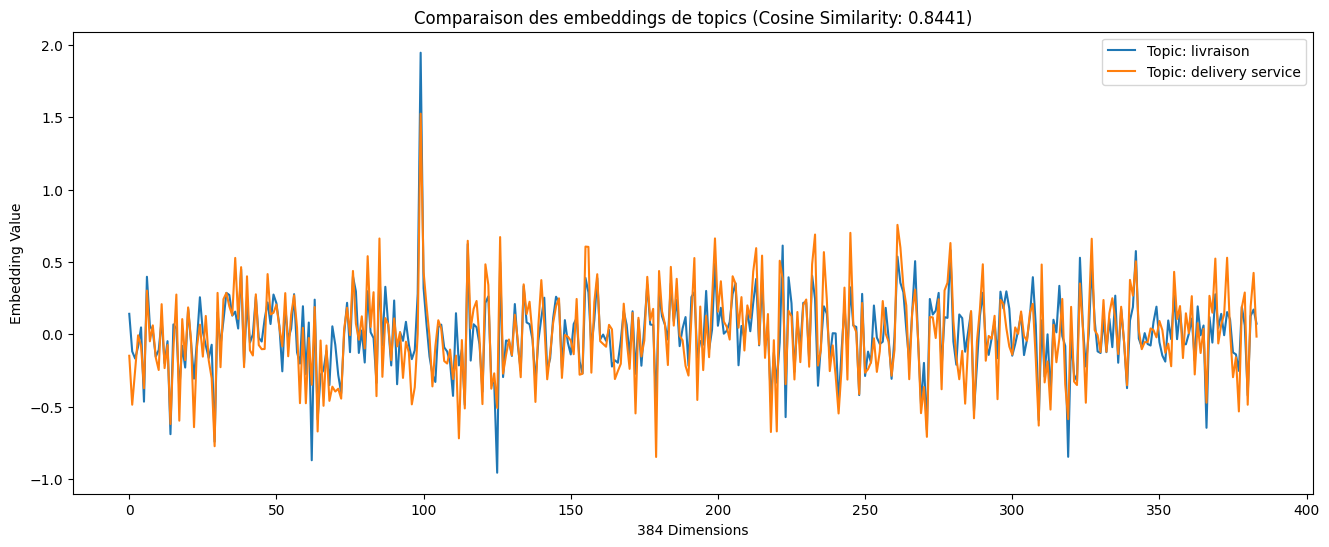

In [104]:
k,l=0,1
PlotCompareEmbeding(df11_topics_embeddings[k], f"Topic: {lstTopics[k]}", df11_topics_embeddings[l], f"Topic: {lstTopics[l]}", Title="Comparaison des embeddings de topics")

In [70]:
df11_topics_embeddings

array([[-0.1489512 , -0.48750257, -0.24417496, ...,  0.1924777 ,
         0.4244428 , -0.01628412],
       [-0.15760963, -0.13393408, -0.03891607, ..., -0.0685932 ,
        -0.49368253,  0.3010766 ],
       [-0.3724586 , -0.01348895, -0.25278178, ..., -0.29489884,
         0.3649192 ,  0.1613972 ],
       ...,
       [-0.6876415 ,  0.06365646, -0.30904624, ..., -0.44111973,
         0.36986077,  0.23308623],
       [-0.1519934 , -0.17298514, -0.31449884, ..., -0.35835573,
        -0.22737382,  0.00755329],
       [-0.607559  , -0.13408743, -0.2935253 , ..., -0.03546043,
         0.08644261,  0.38282812]], shape=(10, 384), dtype=float32)

In [132]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Les centres d'intérêt (Ancres)
print(df11_topics_embeddings.shape) # (11, 384)

# 2. Calcul des scores pour un avis (index i)
# avis_vector: [1, 384], topic_vectors: [4, 384]
for i in np.arange(1000,1020):   #index de l'avis à analyser
    scores = cosine_similarity(df40_comments_emb_GPU[i].reshape(1, -1), df11_topics_embeddings)[0]

    # 3. Seuil de décision (Threshold)
    # Si le score > 0.4, l'avis appartient au topic
    assigned_topics = [lstTopics[j] for j, score in enumerate(scores) if score > 0.25]
    d=dict(zip(lstTopics, scores))
    
    print(
        f"Avis {i}: {df40_comments['commentaire'].iloc[i]}"
       ,f"Scores : {sorted(d.items(), key=lambda x: x[1], reverse=True)[:5]}" # Affiche les 5 topics les plus proches avec leurs scores
       ,f"Topics assignés : {assigned_topics}"
       ,"\n"
    , sep="\n"
    )

(13, 384)
Avis 1000: La première fois commandé chez Oscar satisfait de qualité et délais
Scores : [('quality', np.float32(0.29882947)), ('prix', np.float32(0.2784803)), ('order', np.float32(0.23600812)), ('website', np.float32(0.22479235)), ('commande', np.float32(0.21086353))]
Topics assignés : ['prix', 'quality']


Avis 1001: 3 livraisons dans 2 endroits différent incompréhensible nulle
Scores : [('livraison', np.float32(0.5451766)), ('delivery service', np.float32(0.4075743)), ('order', np.float32(0.3193015)), ('prix', np.float32(0.29018396)), ('product', np.float32(0.28958377))]
Topics assignés : ['livraison', 'delivery service', 'order', 'product', 'prix']


Avis 1002: Site où l'on trouve toutes les pièces dont on a besoin. La livraison est rapide.
Scores : [('livraison', np.float32(0.46002442)), ('website', np.float32(0.43833268)), ('delivery service', np.float32(0.40309203)), ('product', np.float32(0.2895516)), ('service', np.float32(0.28631005))]
Topics assignés : ['livraison',

In [58]:
scores

array([0.06699167, 0.27490073, 0.32755697, 0.15287013, 0.13490283,
       0.06775216, 0.24177828, 0.08976224, 0.21665569, 0.2504251 ],
      dtype=float32)

## 2. La méthode "BERTopic" (La plus sophistiquée)
Il utilise les embeddings pour créer des clusters, mais il permet à un document d'avoir une distribution de probabilités sur plusieurs clusters.

Réduction de dimension (UMAP) : les 384 dimensions sont compressées en 5 ou 10 dimensions clés.

Clustering (HDBSCAN) : Détecte les groupes naturels d'avis.

Multi-topic : En utilisant l'option calculate_probabilities=True, on obtient pour chaque avis un score pour chaque cluster détecté.

uv add bertopic umap-learn hdbscan

In [ ]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# 1. Préparation de la réduction de dimension (UMAP)
# On réduit de 384 à 5 dimensions pour aider le clustering
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# 2. Préparation du clustering (HDBSCAN)
# min_cluster_size: taille mini d'un sujet (ex: 50 avis)
hdbscan_model = HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
, prediction_data=True)

# 3. Création du modèle BERTopic
# On passe embedding_model=None car on va fournir les vecteurs nous-mêmes
topic_model = BERTopic(embedding_model=None, # On ne veut pas que BERTopic génère ses propres embeddings
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  language="multilingual", # Important pour le prétraitement (stopwords, etc.)
  calculate_probabilities=True, # CRUCIAL pour le multi-topic
  verbose=True,
  nr_topics=10
)

# 4. Fit : On donne les textes ET les vecteurs GPU
topics, probs = topic_model.fit_transform(df40_comments['commentaire'].tolist(), embeddings=df40_comments_emb_GPU)

c:\Users\lione\Documents\GitHub\Supply-Chain-Reviews\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.

## Gérer le Multi-Topic (Multi-Classe)
Grâce à calculate_probabilities=True, chaque avis n'est plus coincé dans un seul groupe. 
La variable probs contient les scores d'appartenance de chaque avis à chaque topic.

In [107]:
# Imaginons qu'on veuille les topics pour l'avis n°42
# On définit un seuil (threshold) de 10% de probabilité
threshold = 0.10
avis_probs = probs[40]
potential_topics = [i for i, p in enumerate(avis_probs) if p > threshold]

print(f"L'avis appartient aux topics : {potential_topics}")
# Pour voir le nom des topics :
print(topic_model.get_topic_info().iloc[potential_topics])

L'avis appartient aux topics : [6]
   Topic  Count                             Name  \
6      5   1249  5_carton_ouvert_colis_emballage   

                                                                        Representation  \
6  [carton, ouvert, colis, emballage, lemballage, tait, arriv, dans, le, heureusement]   

                                                                                                                                                           Representative_Docs  
6  [Bien reçu mais mal emballé le carton était ouvert, colis arrivé complétement explosé, le carton était trop léger et pas prévu pour la pièce, Reçu carton écrasé et ouvert]  


In [ ]:
# À lancer dans un notebook pour épater la galerie en réunion
import nbformat
#topic_model.visualize_topics()
topic_model.visualize_barchart()
topic_model.visualize_hierarchy()

NameError: name 'topic_model' is not defined

In [111]:
# Affiche les 10 thèmes les plus fréquents
df_topics = topic_model.get_topic_info().head(11) # head(11) car le topic -1 est le "bruit"
print(df_topics[['Topic', 'Count', 'Name']])

    Topic  Count                                  Name
0      -1  11151                 -1_la_de_livraison_et
1       0   2634                  0_long_trop_jours_le
2       1   2260           1_prix_qualit_rapport_choix
3       2   1825                  2_oscaro_chez_je_sur
4       3   1495           3_vhicule_voiture_mon_pices
5       4   1440  4_vhicule_plaque_ne_dimmatriculation
6       5   1249       5_carton_ouvert_colis_emballage
7       6    973            6_bien_parfait_produit_trs
8       7    966        7_site_facile_dutilisation_trs
9       8    836   8_rapide_livraison_rapidit_conforme
10      9    725     9_efficace_rapide_rapidit_parfait


In [121]:
import pandas as pd

# On crée une matrice de probabilités lisible
prob_df = pd.DataFrame(probs)
#display(prob_df)
# On cherche les avis qui dépassent 0.15 de probabilité sur au moins 2 topics
multi_topic_mask = (prob_df > 0.15).sum(axis=1) >= 2
indices_multi = prob_df.index[multi_topic_mask].tolist()

print(f"Nombre d'avis multi-thématiques détectés : {len(indices_multi)}")

# Voir un exemple concret d'avis multi-topic
if indices_multi:
    idx = indices_multi[0]
    print(f"\nAvis n°{idx} : {df40_comments.loc[idx].commentaire}")
    # On affiche les thèmes associés
    top_indices = prob_df.iloc[idx].nlargest(3)
    for t_idx, p in top_indices.items():
        if p > 0.1:
            print(f" -> Topic {t_idx} (Confiance: {p:.2f}): {topic_model.get_topic(t_idx)[:3]}")

Nombre d'avis multi-thématiques détectés : 1

Avis n°31746 : Trop long et relais à remplacer à la dernière minute
 -> Topic 105 (Confiance: 0.18): [('trop', np.float64(0.2223645858188329)), ('longue', np.float64(0.21942717112335394)), ('long', np.float64(0.1269919560995434))]
 -> Topic 0 (Confiance: 0.16): [('long', np.float64(0.0125344911847251)), ('trop', np.float64(0.010864289188406786)), ('jours', np.float64(0.010761783591760608))]


In [122]:
len(indices_multi)

1

In [129]:
def benchmark_thresholds(probs_matrix):
    probs_array = np.array(probs_matrix)
    for t in np.arange(0, 0.20, 0.01):
        # 1. On crée un masque booléen (True là où c'est > t)
        mask = probs_array > t
        
        # 2. On compte combien de True par ligne (axis=1)
        counts_per_row = np.sum(mask, axis=1)
        
        # 3. On compte combien de lignes ont un score > 1
        count = np.sum(counts_per_row > 1)
        
        perc = (count / len(probs_array)) * 100
        print(f"Seuil {t:.2f} : {count} avis multi-labels ({perc:.1f}%)")

benchmark_thresholds(probs)

probs

Seuil 0.00 : 39924 avis multi-labels (100.0%)
Seuil 0.01 : 28954 avis multi-labels (72.5%)
Seuil 0.02 : 22598 avis multi-labels (56.6%)
Seuil 0.03 : 14885 avis multi-labels (37.3%)
Seuil 0.04 : 8293 avis multi-labels (20.8%)
Seuil 0.05 : 3603 avis multi-labels (9.0%)
Seuil 0.06 : 1548 avis multi-labels (3.9%)
Seuil 0.07 : 610 avis multi-labels (1.5%)
Seuil 0.08 : 191 avis multi-labels (0.5%)
Seuil 0.09 : 61 avis multi-labels (0.2%)
Seuil 0.10 : 22 avis multi-labels (0.1%)
Seuil 0.11 : 12 avis multi-labels (0.0%)
Seuil 0.12 : 4 avis multi-labels (0.0%)
Seuil 0.13 : 1 avis multi-labels (0.0%)
Seuil 0.14 : 1 avis multi-labels (0.0%)
Seuil 0.15 : 1 avis multi-labels (0.0%)
Seuil 0.16 : 0 avis multi-labels (0.0%)
Seuil 0.17 : 0 avis multi-labels (0.0%)
Seuil 0.18 : 0 avis multi-labels (0.0%)
Seuil 0.19 : 0 avis multi-labels (0.0%)


array([[2.65705620e-002, 7.26300567e-003, 1.44310545e-002, ...,
        1.54536457e-003, 1.50151558e-003, 7.71737379e-003],
       [2.33016973e-308, 2.35553004e-308, 2.21252814e-308, ...,
        4.33939490e-308, 3.79265635e-308, 2.37870441e-308],
       [3.00458202e-003, 4.59987631e-003, 2.15290391e-003, ...,
        7.46369116e-004, 7.72520320e-004, 7.74670444e-003],
       ...,
       [1.91571558e-307, 1.10796038e-307, 1.25638501e-307, ...,
        2.43587986e-308, 2.48711195e-308, 1.25598840e-307],
       [2.19608313e-003, 2.57972940e-003, 1.86325226e-003, ...,
        8.49992361e-004, 9.05779358e-004, 3.55423045e-003],
       [5.15561789e-003, 1.16969640e-002, 3.37789748e-003, ...,
        1.11553482e-003, 1.23890043e-003, 6.36271833e-003]],
      shape=(39924, 116))

In [ ]:
#AVOIR

# On définit des thèmes "ancres" pour guider le modèle
seed_topic_list = [
    ["livraison", "transporteur", "colis", "paquet"],
    ["délais", "retard", "attente", "rapide"],
    ["prix", "cher", "coût", "frais", "argent"]
]

topic_model = BERTopic(
    seed_topic_list=seed_topic_list,
    umap_model=umap_model, 
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True
)
# Relancez le fit avec les vecteurs NPU
topics, probs = topic_model.fit_transform(avis_40000, embeddings=final_matrix)